# ENERGIEANALYSE ORAC - 2024 vs 2025

## Stap 1 import libraries

In [27]:
# ============================================================
# GLOBALE KLEURSCHEMA - GEBRUIK OVERAL
# ============================================================

KLEUREN = {
    'Productie': '#F1C40F',      # Geel ☀️
    'Afname': '#E74C3C',         # Rood 🔴
    'Injectie': '#27AE60',       # Groen 💚
    'Totaal Verbruik': '#8E44AD'  # Paars 💜
}

MARKERS = {
    'Productie': '^',
    'Afname': 's',
    'Injectie': 'D',
    'Totaal Verbruik': 'o'
}

print("✓ Kleurschema geladen:")
for param, color in KLEUREN.items():
    print(f"  {param}: {color}")

✓ Kleurschema geladen:
  Productie: #F1C40F
  Afname: #E74C3C
  Injectie: #27AE60
  Totaal Verbruik: #8E44AD


In [28]:
"""
ENERGIEANALYSE 2024 vs 2025 - VERSIE 2
Simpel, stap-voor-stap
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Taal instellingen
plt.rcParams['figure.figsize'] = (14, 6)


## Stap 2 Data inladen

In [29]:
df_2024 = pd.read_excel(r'C:\Users\Badra\Nieuwe map\Howest\Project duurzameplan\Data\energie_orac_2024.xlsx')
df_2025 = pd.read_excel(r'C:\Users\Badra\Nieuwe map\Howest\Project duurzameplan\Data\energie_orac_2025.xlsx')

df_2024['datetime'] = pd.to_datetime(df_2024['datetime'])
df_2025['datetime'] = pd.to_datetime(df_2025['datetime'])

print(f"✓ 2024: {len(df_2024)} records ({df_2024['datetime'].min()} tot {df_2024['datetime'].max()})")
print(f"✓ 2025: {len(df_2025)} records ({df_2025['datetime'].min()} tot {df_2025['datetime'].max()})")


✓ 2024: 35136 records (2024-01-01 00:00:00 tot 2024-12-31 23:45:00)
✓ 2025: 29192 records (2025-01-01 00:00:00 tot 2025-10-31 23:45:00)


## Stap 3 Totaal verbruik

In [30]:
df_2024['totaalverbruik'] = df_2024['productie_kwh'] + df_2024['afname_kwh'] - df_2024['injectie_kwh']
df_2025['totaalverbruik'] = df_2025['productie_kwh'] + df_2025['afname_kwh'] - df_2025['injectie_kwh']

print("Formule: Totaal verbruik = Productie + Afname - Injectie")
print("\n✓ Berekend!")

Formule: Totaal verbruik = Productie + Afname - Injectie

✓ Berekend!


## Stap 4 Datum

In [31]:
for df in [df_2024, df_2025]:
    df['maand'] = df['datetime'].dt.month
    df['maand_naam'] = df['datetime'].dt.strftime('%B')
    df['week'] = df['datetime'].dt.isocalendar().week
    df['weekdag'] = df['datetime'].dt.weekday
    df['dag_naam'] = df['datetime'].dt.day_name()
    df['is_weekend'] = df['weekdag'].isin([5, 6]).astype(int)

print("✓ Datum kolommen toegevoegd\n")

✓ Datum kolommen toegevoegd



In [32]:
# ============================================================
# GLOBALE KLEURSCHEMA - GEBRUIK OVERAL
# ============================================================

# Definieer kleuren eenmaal
KLEUREN = {
    'Productie': '#F1C40F',      # Geel ☀️
    'Afname': '#E74C3C',         # Rood 🔴
    'Injectie': '#27AE60',       # Groen 💚
    'Verbruik': '#8E44AD'        # Paars 💜
}

# Markers per parameter
MARKERS = {
    'Productie': '^',            # Driehoek
    'Afname': 's',               # Vierkant
    'Injectie': 'D',             # Ruit
    'Verbruik': 'o'              # Cirkel
}

print("\n✓ Kleurschema geladen:")
for param, color in KLEUREN.items():
    print(f"  {param}: {color}")


✓ Kleurschema geladen:
  Productie: #F1C40F
  Afname: #E74C3C
  Injectie: #27AE60
  Verbruik: #8E44AD


# Deel 1

## Stap 5 GRAFIEKEN EN TABELLEN

### Analysse per jaar

ANALYSE: PER JAAR

             2024 (kWh)    2025 (kWh)
Productie  1.221227e+06  1.100410e+06
Afname     1.659056e+06  1.400352e+06
Injectie   5.294683e+05  3.652495e+05
Verbruik   2.350815e+06  2.132715e+06



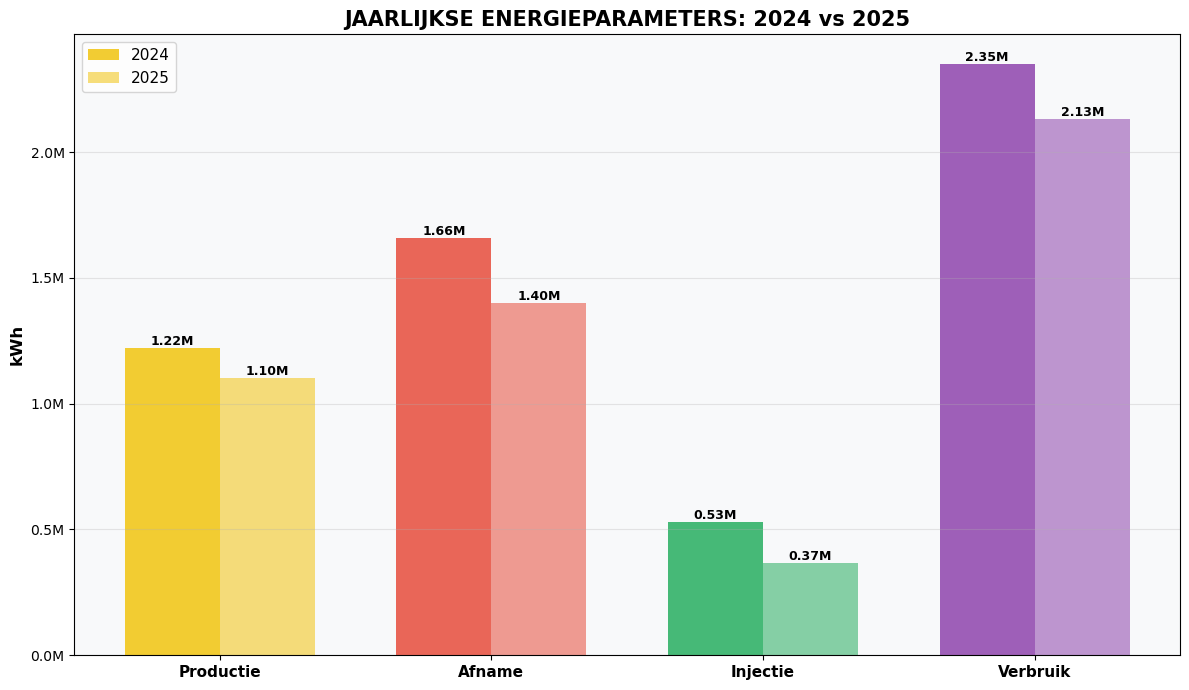

In [33]:
print("="*80)
print("ANALYSE: PER JAAR")
print("="*80)

jaar_2024 = {
    'Productie': df_2024['productie_kwh'].sum(),
    'Afname': df_2024['afname_kwh'].sum(),
    'Injectie': df_2024['injectie_kwh'].sum(),
    'Verbruik': df_2024['totaalverbruik'].sum(),
}

jaar_2025 = {
    'Productie': df_2025['productie_kwh'].sum(),
    'Afname': df_2025['afname_kwh'].sum(),
    'Injectie': df_2025['injectie_kwh'].sum(),
    'Verbruik': df_2025['totaalverbruik'].sum(),
}

tabel = pd.DataFrame({
    '2024 (kWh)': jaar_2024,
    '2025 (kWh)': jaar_2025
})

print(f"\n{tabel.to_string()}\n")

# ============================================================
# GRAFIEK - MET GLOBALE KLEUREN
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(jaar_2024))
width = 0.35

# Gebruik GLOBALE KLEUREN dictionary
for i, (param, val_24) in enumerate(jaar_2024.items()):
    val_25 = jaar_2025[param]
    color = KLEUREN[param]  # Haal kleur uit globale dictionary
    
    ax.bar(i - width/2, val_24, width, label='2024' if i == 0 else '', 
           alpha=0.85, color=color)
    ax.bar(i + width/2, val_25, width, label='2025' if i == 0 else '', 
           alpha=0.55, color=color)
    
    # Voeg waardes toe
    ax.text(i - width/2, val_24, f'{val_24/1e6:.2f}M', 
           ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.text(i + width/2, val_25, f'{val_25/1e6:.2f}M', 
           ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('kWh', fontsize=12, fontweight='bold')
ax.set_title('JAARLIJKSE ENERGIEPARAMETERS: 2024 vs 2025', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(jaar_2024.keys(), fontsize=11, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#F8F9FA')

# Format Y-as in miljoen
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

### ANALYSE: PER MAAND


TABEL: 2024 - Per maand
maand_naam  productie_kwh  afname_kwh  injectie_kwh  totaalverbruik
   January   31994.057025  177133.750       5510.22   203617.587025
  February   44135.836142  167550.000      11907.25   199778.586142
     March   94821.619992  132494.375      36323.43   190992.564993
     April  146464.818874  127185.625      68474.40   205176.043874
       May  188838.638384  122570.000      81236.30   230172.338385
      June  197613.317329   97824.375     100535.39   194902.302329
      July  172884.428215  126020.625      80547.53   218357.523215
    August  144592.467342   87560.625      84668.86   147484.232342
 September   96806.451312  150943.125      39847.20   207902.376312
   October   62823.425502  179811.250      13361.76   229272.915502
  November   24056.415500  159057.500       4197.02   178916.895500
  December   16195.857688  130905.000       2858.90   144241.957688

TABEL: 2025 - Per maand
maand_naam  productie_kwh  afname_kwh  injectie_kwh  totaalverbrui

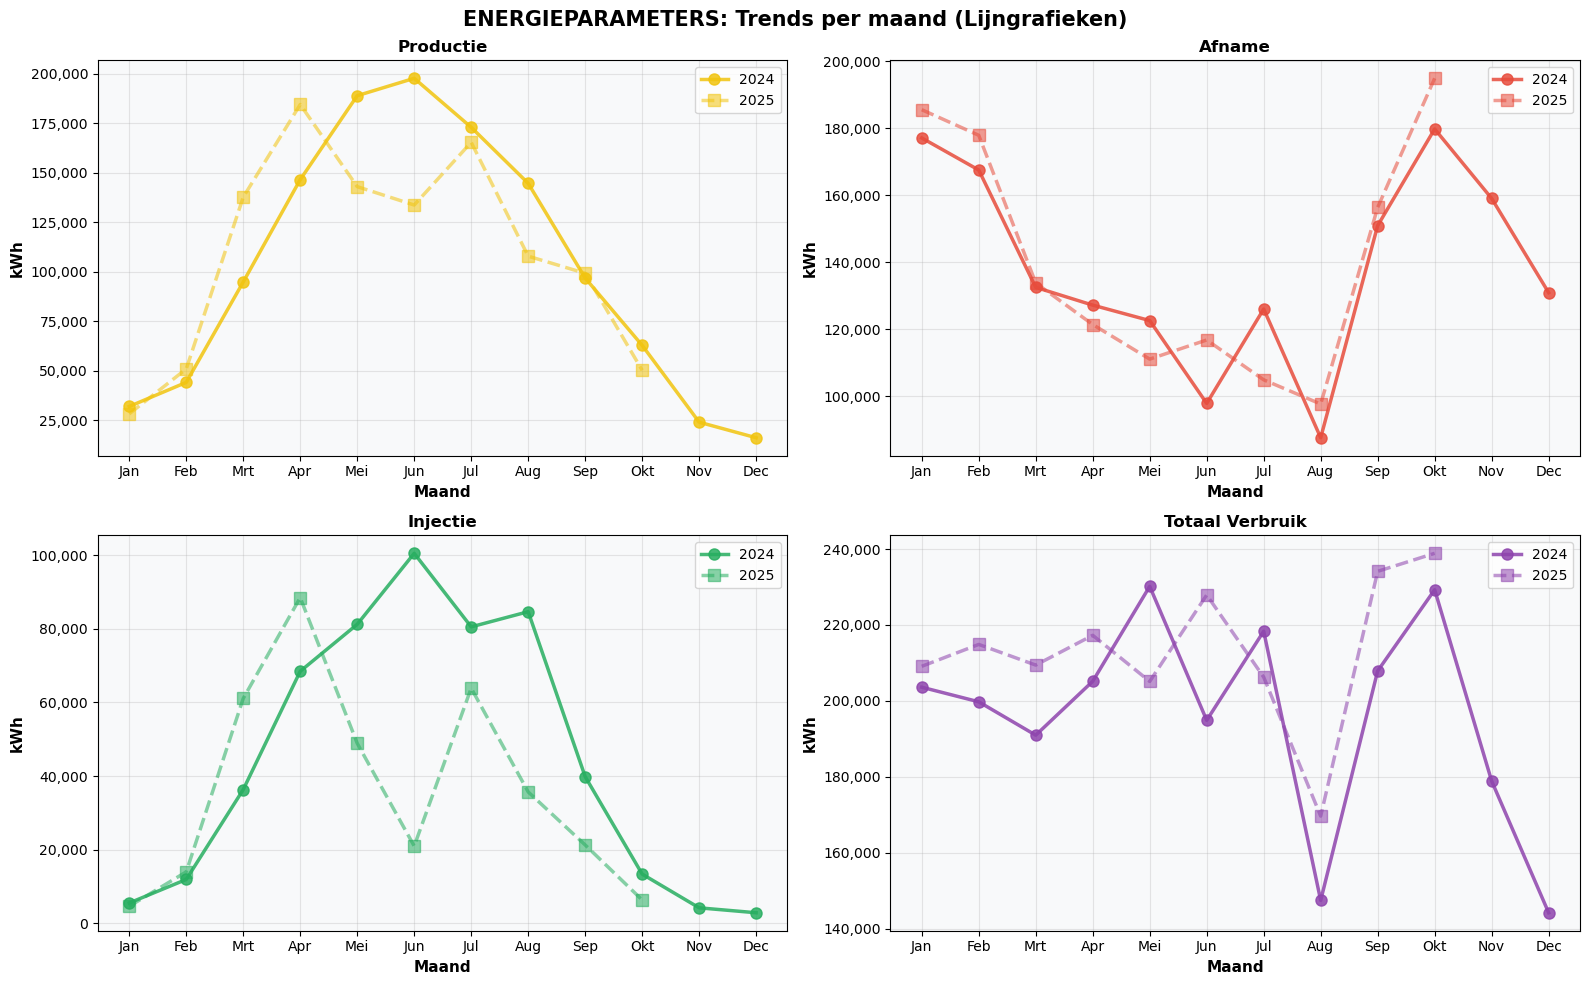

In [34]:
maand_2024 = df_2024.groupby(['maand', 'maand_naam']).agg({
    'productie_kwh': 'sum',
    'afname_kwh': 'sum',
    'injectie_kwh': 'sum',
    'totaalverbruik': 'sum'
}).reset_index()

maand_2025 = df_2025.groupby(['maand', 'maand_naam']).agg({
    'productie_kwh': 'sum',
    'afname_kwh': 'sum',
    'injectie_kwh': 'sum',
    'totaalverbruik': 'sum'
}).reset_index()

print("\nTABEL: 2024 - Per maand")
print(maand_2024[['maand_naam', 'productie_kwh', 'afname_kwh', 'injectie_kwh', 'totaalverbruik']].to_string(index=False))

print("\nTABEL: 2025 - Per maand")
print(maand_2025[['maand_naam', 'productie_kwh', 'afname_kwh', 'injectie_kwh', 'totaalverbruik']].to_string(index=False))

# ============================================================
# LIJNGRAFIEKEN (TRENDS ZIEN) - MET GLOBALE KLEUREN
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ENERGIEPARAMETERS: Trends per maand (Lijngrafieken)', fontsize=15, fontweight='bold')

params = ['productie_kwh', 'afname_kwh', 'injectie_kwh', 'totaalverbruik']
labels = ['Productie', 'Afname', 'Injectie', 'Totaal Verbruik']  # EXACT hetzelfde als in KLEUREN!


for ax, param, label in zip(axes.flat, params, labels):
    color = KLEUREN.get(label.replace('Totaal ', ''), '#8E44AD')
    
    # 2024 = solid line (voller)
    ax.plot(maand_2024['maand'], maand_2024[param], marker='o', linewidth=2.5, 
            label='2024', markersize=8, color=color, alpha=0.85, linestyle='-')
    
    
    # 2025 = dashed line (lichter)
    ax.plot(maand_2025['maand'], maand_2025[param], marker='s', linewidth=2.5, 
            label='2025', markersize=8, color=color, alpha=0.55, linestyle='--')
    
    ax.set_xlabel('Maand', fontsize=11, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=11, fontweight='bold')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mrt', 'Apr', 'Mei', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec'])
    ax.set_facecolor('#F8F9FA')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

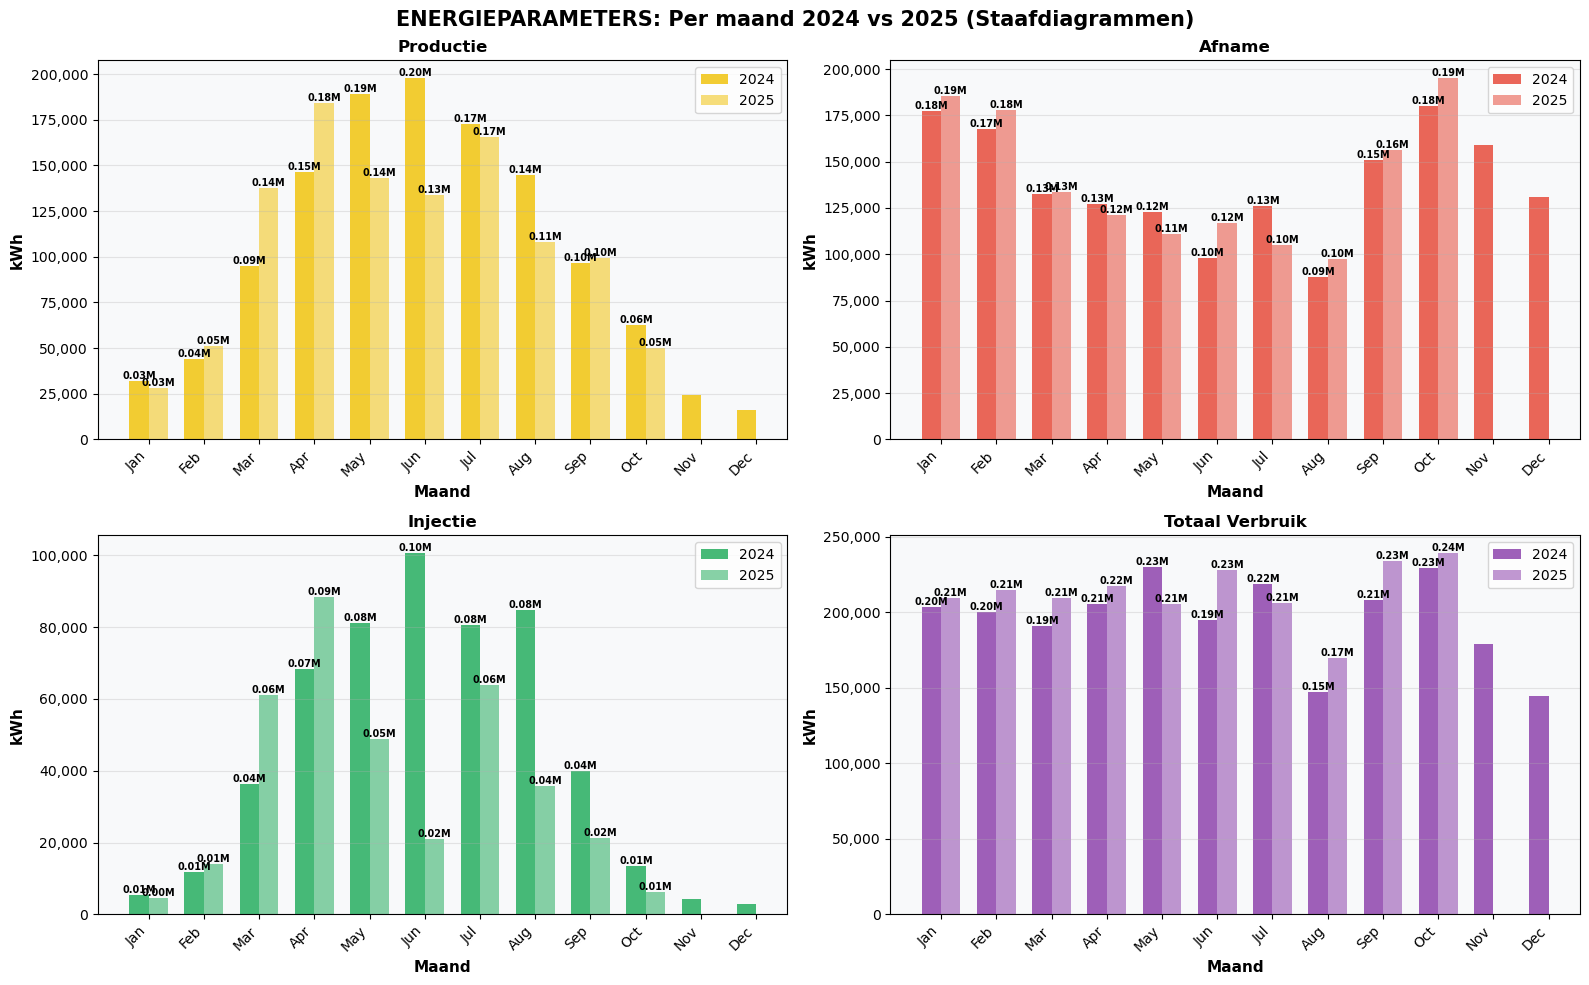

In [35]:
# ============================================================
# STAAFDIAGRAMMEN (VERGELIJKING) - MET GLOBALE KLEUREN
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ENERGIEPARAMETERS: Per maand 2024 vs 2025 (Staafdiagrammen)', fontsize=15, fontweight='bold')

params = ['productie_kwh', 'afname_kwh', 'injectie_kwh', 'totaalverbruik']
labels = ['Productie', 'Afname', 'Injectie', 'Totaal Verbruik']  # EXACT hetzelfde!

for ax, param, label in zip(axes.flat, params, labels):
    x_2024 = np.arange(len(maand_2024))
    width = 0.35
    
    color = KLEUREN.get(label.replace('Totaal ', ''), '#8E44AD')  # Nu werkt het!
    
    # 2024 bars
    bars1 = ax.bar(x_2024 - width/2, maand_2024[param], width, label='2024', 
                   alpha=0.85, color=color)
    
    # 2025 bars
    bars2 = ax.bar(x_2024[:len(maand_2025)] + width/2, maand_2025[param], width, label='2025', 
                   alpha=0.55, color=color)
    
    # Voeg ECHTE WAARDES toe (M-format)
    for i, (v24, v25) in enumerate(zip(maand_2024[param], maand_2025[param])):
        ax.text(i - width/2, v24, f'{v24/1e6:.2f}M', 
               ha='center', va='bottom', fontsize=7, fontweight='bold')
        ax.text(i + width/2, v25, f'{v25/1e6:.2f}M', 
               ha='center', va='bottom', fontsize=7, fontweight='bold')
    
    # Opmaak
    ax.set_xlabel('Maand', fontsize=11, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=11, fontweight='bold')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(maand_2024)))
    ax.set_xticklabels(maand_2024['maand_naam'].str[:3], rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_facecolor('#F8F9FA')
    
    # Y-as in kWh (EXACTE WAARDES, geen M-format)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### ANALYSE: PER WEEK (eerste 26 weken)


TABEL: 2024 - Eerste 10 weken
 week  productie_kwh  afname_kwh  injectie_kwh  totaalverbruik
    1    4826.765433   31896.250       1093.79    35629.225433
    2    5995.938141   44870.625         36.88    50829.683141
    3    8120.076125   38384.375       1234.44    45270.011125
    4    9988.798488   41148.125       3221.34    47915.583488
    5   10715.165502   36161.250       2260.72    44615.695502
    6    7207.934848   46710.625       1768.84    52149.719848
    7   12350.871585   37943.750       3050.10    47244.521585
    8   10874.725511   37373.125       4160.70    44087.150511
    9   12426.012974   40664.375       3317.63    49772.757974
   10   22892.543988   32866.250       8367.02    47391.773987

TABEL: 2025 - Eerste 10 weken
 week  productie_kwh  afname_kwh  injectie_kwh  totaalverbruik
    1    3102.142318    6385.625       1153.20     8334.567318
    2    7279.019656   43681.250       1856.31    49103.959656
    3    5164.247744   45947.500         59.38    51052.

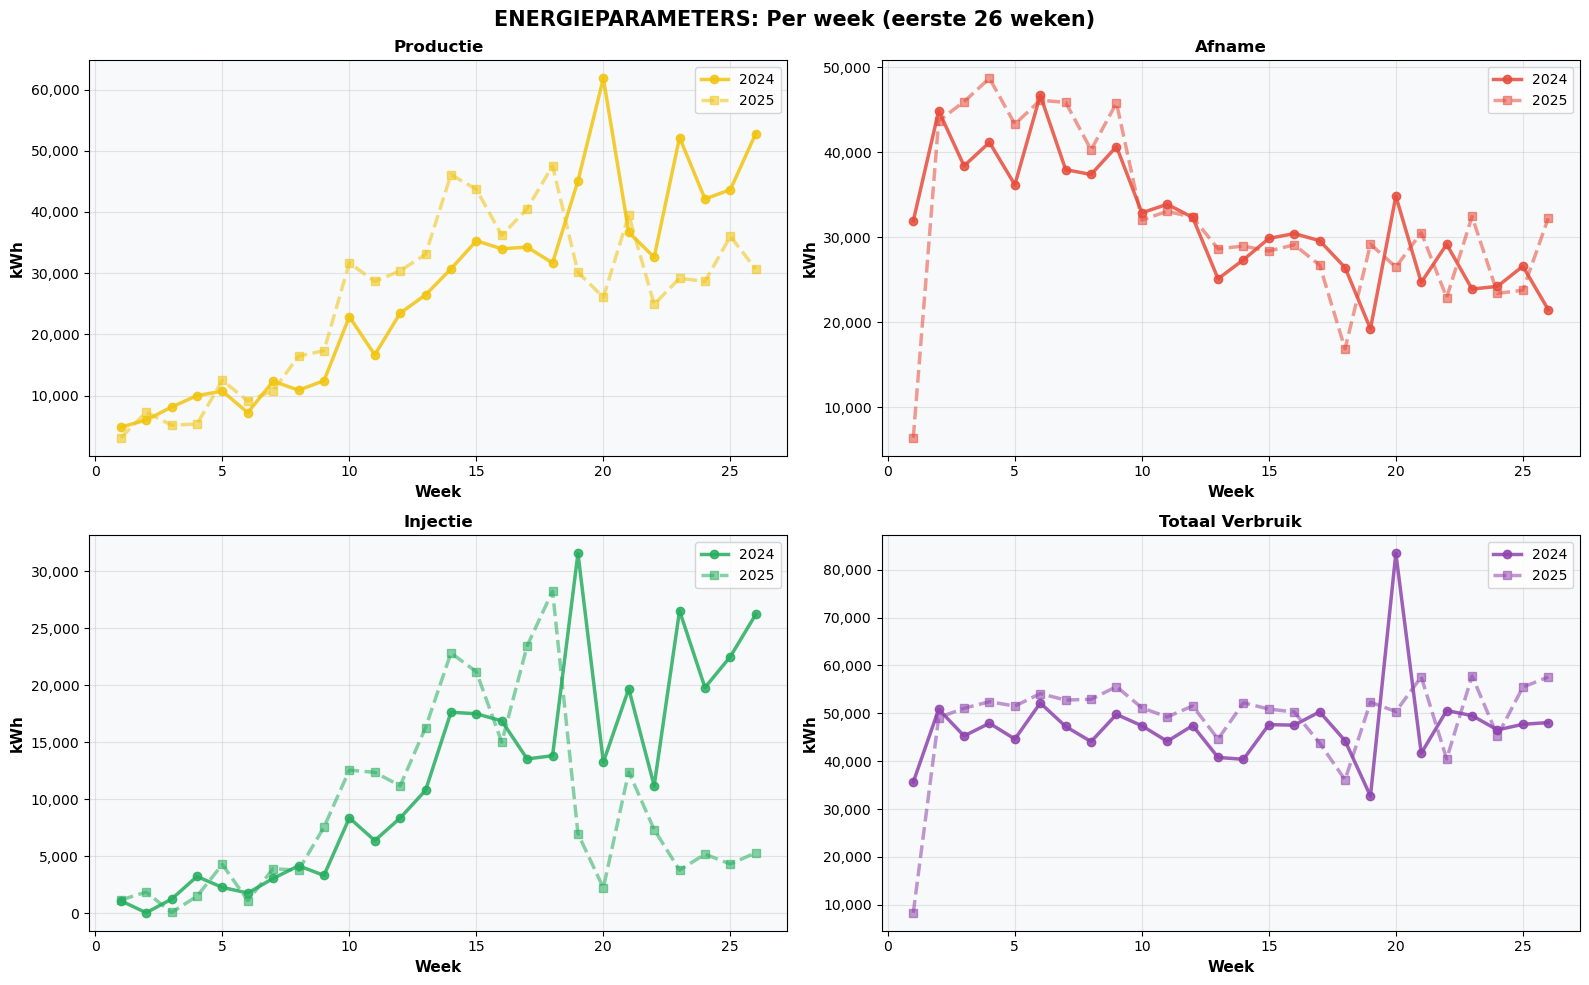

In [52]:
week_2024 = df_2024.groupby('week').agg({
    'productie_kwh': 'sum',
    'afname_kwh': 'sum',
    'injectie_kwh': 'sum',
    'totaalverbruik': 'sum'
}).reset_index()

week_2025 = df_2025.groupby('week').agg({
    'productie_kwh': 'sum',
    'afname_kwh': 'sum',
    'injectie_kwh': 'sum',
    'totaalverbruik': 'sum'
}).reset_index()

print("\nTABEL: 2024 - Eerste 10 weken")
print(week_2024[week_2024['week'] <= 10].to_string(index=False))

print("\nTABEL: 2025 - Eerste 10 weken")
print(week_2025[week_2025['week'] <= 10].to_string(index=False))

# ============================================================
# LIJNGRAFIEKEN - MET GLOBALE KLEUREN
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ENERGIEPARAMETERS: Per week (eerste 26 weken)', fontsize=15, fontweight='bold')

params = ['productie_kwh', 'afname_kwh', 'injectie_kwh', 'totaalverbruik']
labels = ['Productie', 'Afname', 'Injectie', 'Totaal Verbruik']

for ax, param, label in zip(axes.flat, params, labels):
    color = KLEUREN.get(label.replace('Totaal ', ''), '#8E44AD')

    data_24 = week_2024[week_2024['week'] <= 26]
    data_25 = week_2025[week_2025['week'] <= 26]
    
    params = ['productie_kwh', 'afname_kwh', 'injectie_kwh', 'totaalverbruik']
    labels = ['Productie', 'Afname', 'Injectie', 'Verbruik']
    
    # 2024 = solid line (voller), 2025 = dashed line (lichter)
    ax.plot(data_24['week'], data_24[param], marker='o', linewidth=2.5, 
            label='2024', markersize=6, alpha=0.85, color=color, linestyle='-')
    ax.plot(data_25['week'], data_25[param], marker='s', linewidth=2.5, 
            label='2025', markersize=6, alpha=0.55, color=color, linestyle='--')
    
    ax.set_xlabel('Week', fontsize=11, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=11, fontweight='bold')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_facecolor('#F8F9FA')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### ANALYSE: PER WEEKDAG


TABEL: 2024 - Per weekdag
   dag_nl  productie_kwh  afname_kwh  injectie_kwh  totaalverbruik
  Maandag  177891.544512  302729.375      49878.26   430742.659512
  Dinsdag  159192.681550  356300.000      31957.61   483535.071550
 Woensdag  187824.193740  335101.875      48677.94   474248.128741
Donderdag  177499.928974  327704.375      45147.29   460057.013974
  Vrijdag  172034.915604  230661.875      61504.08   341192.710604
 Zaterdag  171290.211370   39053.125     144988.73    65354.606370
   Zondag  175493.857555   67505.625     147314.35    95685.132555

TABEL: 2025 - Per weekdag
   dag_nl  productie_kwh  afname_kwh  injectie_kwh  totaalverbruik
  Maandag  179583.045116  251362.500  40963.560000   389135.110116
  Dinsdag  176589.092295  285440.625  29340.448504   431876.153791
 Woensdag  167583.806857  283578.125  30963.350000   419342.331857
Donderdag  161266.235589  274832.500  31090.524796   405020.710793
  Vrijdag  173987.768363  203035.000  51040.651743   325751.491620
 Zaterda

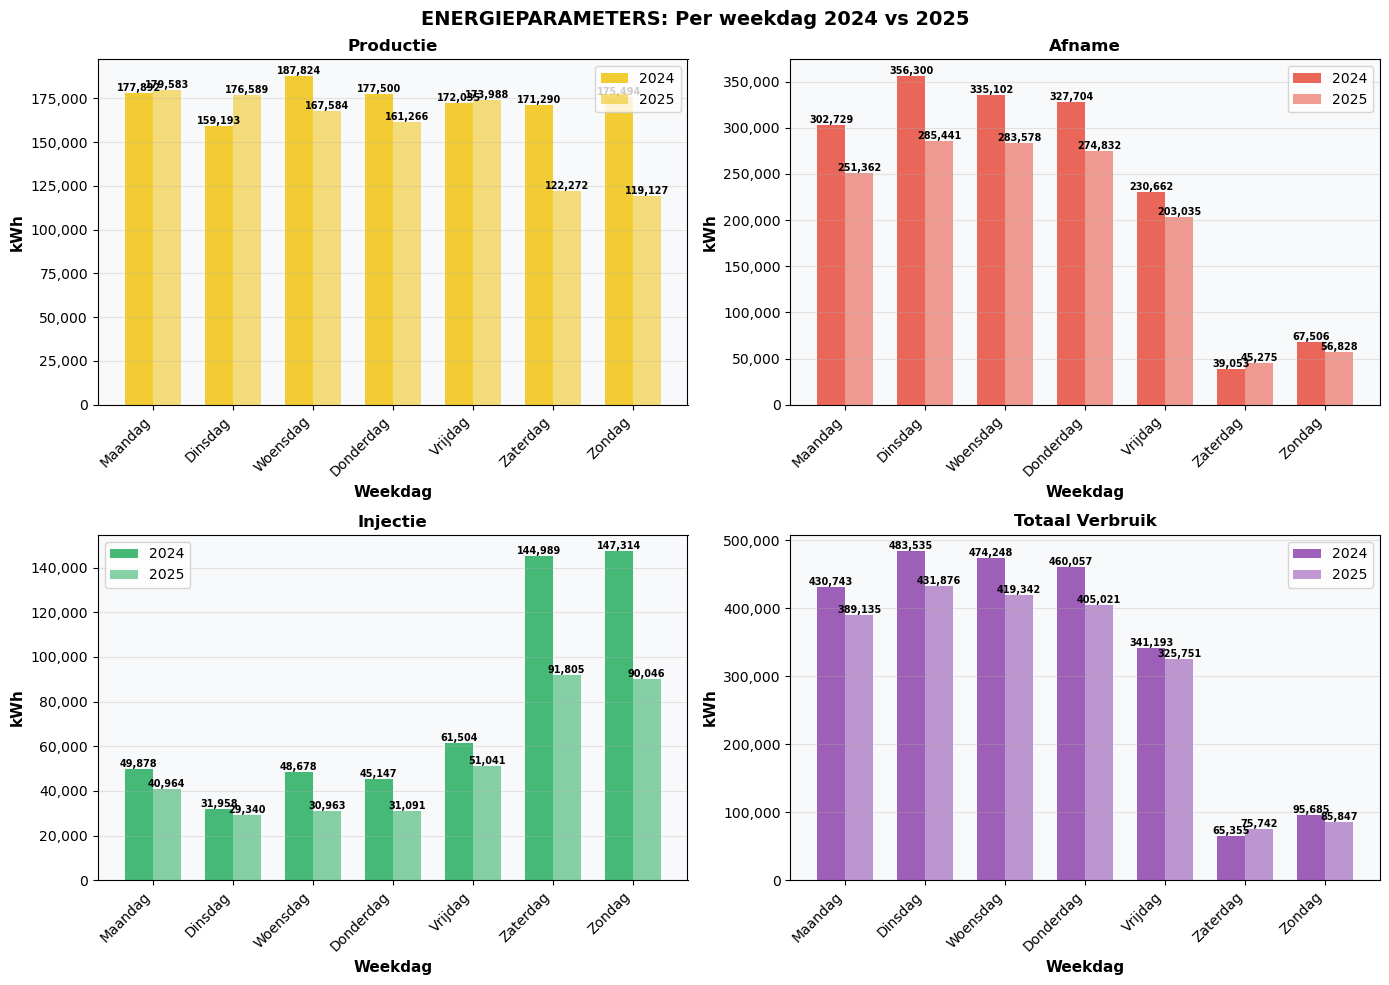

In [57]:
weekdag_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekdag_nl = ['Maandag', 'Dinsdag', 'Woensdag', 'Donderdag', 'Vrijdag', 'Zaterdag', 'Zondag']

weekdag_2024 = df_2024.groupby('dag_naam').agg({
    'productie_kwh': 'sum',
    'afname_kwh': 'sum',
    'injectie_kwh': 'sum',
    'totaalverbruik': 'sum'
}).reindex(weekdag_order).reset_index()
weekdag_2024['dag_nl'] = weekdag_nl

weekdag_2025 = df_2025.groupby('dag_naam').agg({
    'productie_kwh': 'sum',
    'afname_kwh': 'sum',
    'injectie_kwh': 'sum',
    'totaalverbruik': 'sum'
}).reindex(weekdag_order).reset_index()
weekdag_2025['dag_nl'] = weekdag_nl

print("\nTABEL: 2024 - Per weekdag")
print(weekdag_2024[['dag_nl', 'productie_kwh', 'afname_kwh', 'injectie_kwh', 'totaalverbruik']].to_string(index=False))

print("\nTABEL: 2025 - Per weekdag")
print(weekdag_2025[['dag_nl', 'productie_kwh', 'afname_kwh', 'injectie_kwh', 'totaalverbruik']].to_string(index=False))

# ============================================================
# STAAFDIAGRAMMEN - MET GLOBALE KLEUREN
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ENERGIEPARAMETERS: Per weekdag 2024 vs 2025', fontsize=14, fontweight='bold')

params = ['productie_kwh', 'afname_kwh', 'injectie_kwh', 'totaalverbruik']
labels = ['Productie', 'Afname', 'Injectie', 'Totaal Verbruik']

x = np.arange(len(weekdag_nl))
width = 0.35

for ax, param, label in zip(axes.flat, params, labels):
    # DIRECT uit KLEUREN dictionary (EXACT dezelfde keys!)
    color = KLEUREN.get(label.replace('Totaal ', ''), '#8E44AD')
    
    val_24 = weekdag_2024[param].values
    val_25 = weekdag_2025[param].values
    
    # 2024 = voller, 2025 = lichter
    bars1 = ax.bar(x - width/2, val_24, width, label='2024', alpha=0.85, color=color)
    bars2 = ax.bar(x + width/2, val_25, width, label='2025', alpha=0.55, color=color)
    
    # Voeg EXACTE WAARDES toe
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:,.0f}',
                   ha='center', va='bottom', fontsize=7, fontweight='bold')
    
    # Opmaak
    ax.set_xlabel('Weekdag', fontsize=11, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=11, fontweight='bold')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(weekdag_nl, rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_facecolor('#F8F9FA')
    
    # Y-as in kWh (exacte waardes)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [58]:
print("="*80)
print("SAMENVATTING")
print("="*80)

print("\n📊 RESULTATEN:")
print(f"\nProductie:")
print(f"  2024: {jaar_2024['Productie']:>15,.0f} kWh")
print(f"  2025: {jaar_2025['Productie']:>15,.0f} kWh")
pct = ((jaar_2025['Productie'] - jaar_2024['Productie']) / jaar_2024['Productie'] * 100)
print(f"  Verschil: {pct:>14.1f}%")

print(f"\nAfname:")
print(f"  2024: {jaar_2024['Afname']:>15,.0f} kWh")
print(f"  2025: {jaar_2025['Afname']:>15,.0f} kWh")
pct = ((jaar_2025['Afname'] - jaar_2024['Afname']) / jaar_2024['Afname'] * 100)
print(f"  Verschil: {pct:>14.1f}%")

print(f"\nInjectie:")
print(f"  2024: {jaar_2024['Injectie']:>15,.0f} kWh")
print(f"  2025: {jaar_2025['Injectie']:>15,.0f} kWh")
if jaar_2024['Injectie'] > 0:
    pct = ((jaar_2025['Injectie'] - jaar_2024['Injectie']) / jaar_2024['Injectie'] * 100)
else:
    pct = 0
print(f"  Verschil: {pct:>14.1f}%")

print(f"\nTotaal Verbruik:")
print(f"  2024: {jaar_2024['Verbruik']:>15,.0f} kWh")
print(f"  2025: {jaar_2025['Verbruik']:>15,.0f} kWh")
pct = ((jaar_2025['Verbruik'] - jaar_2024['Verbruik']) / jaar_2024['Verbruik'] * 100)
print(f"  Verschil: {pct:>14.1f}%")

SAMENVATTING

📊 RESULTATEN:

Productie:
  2024:       1,221,227 kWh
  2025:       1,100,410 kWh
  Verschil:           -9.9%

Afname:
  2024:       1,659,056 kWh
  2025:       1,400,352 kWh
  Verschil:          -15.6%

Injectie:
  2024:         529,468 kWh
  2025:         365,249 kWh
  Verschil:          -31.0%

Totaal Verbruik:
  2024:       2,350,815 kWh
  2025:       2,132,715 kWh
  Verschil:           -9.3%


# DEEL 2: SPECIFIEKE PERIODES (Stacked Area Charts)

## Grafiek 3: SPECIFIEKE DAG - Stacked Area Chart
**Let op: Pas de datum aan naar je keuze!**


Dag: 2024-06-05
Totaal Verbruik: 9847.9 kWh
Afname: 4437.5 kWh
Productie: 8626.7 kWh
Injectie: 3216.3 kWh


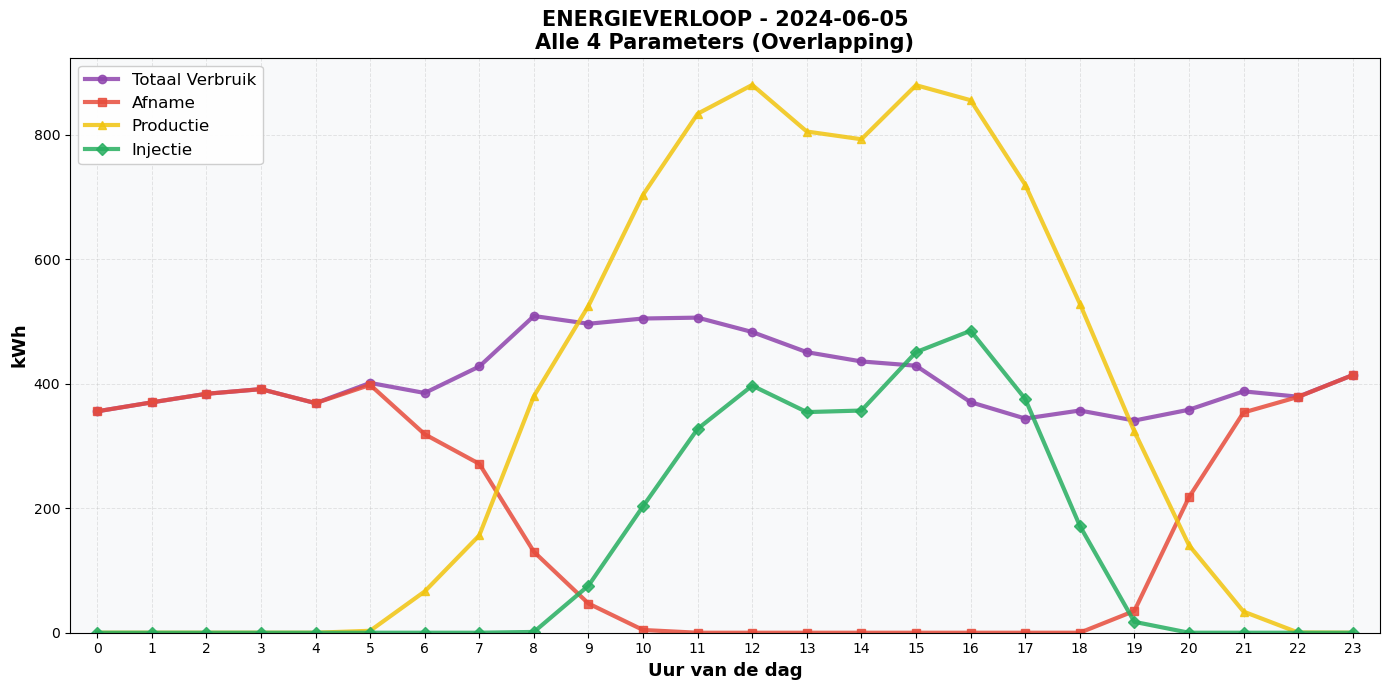


DETAIL PER UUR:
 uur  totaalverbruik  afname_kwh  productie_kwh  injectie_kwh
   0      355.625000     355.625       0.000000          0.00
   1      370.000000     370.000       0.000000          0.00
   2      383.750000     383.750       0.000000          0.00
   3      391.250000     391.250       0.000000          0.00
   4      368.750000     368.750       0.000000          0.00
   5      401.235063     398.125       3.110063          0.00
   6      385.067722     318.750      66.317722          0.00
   7      427.631839     271.250     156.381839          0.00
   8      508.724647     130.000     379.974647          1.25
   9      496.260592      46.875     525.015592         75.63
  10      504.683851       4.375     703.438851        203.13
  11      506.105038       0.000     833.605038        327.50
  12      482.995641       0.000     879.875641        396.88
  13      450.623989       0.000     805.003989        354.38
  14      435.728910       0.000     792.608910      

In [39]:
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====
selected_date = pd.Timestamp('2024-06-05').date()  # Zomerdag
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====

day_data = df_2024[df_2024['datetime'].dt.date == selected_date].copy()
day_data = day_data.sort_values('datetime')

if len(day_data) > 0:
    print(f"\nDag: {selected_date}")
    print(f"Totaal Verbruik: {day_data['totaalverbruik'].sum():.1f} kWh")
    print(f"Afname: {day_data['afname_kwh'].sum():.1f} kWh")
    print(f"Productie: {day_data['productie_kwh'].sum():.1f} kWh")
    print(f"Injectie: {day_data['injectie_kwh'].sum():.1f} kWh")
    
    # Aggregeer per uur
    hourly = day_data.groupby(day_data['datetime'].dt.hour).agg({
        'totaalverbruik': 'sum',
        'afname_kwh': 'sum',
        'productie_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    hourly.columns = ['uur', 'totaalverbruik', 'afname_kwh', 'productie_kwh', 'injectie_kwh']
    
    # OVERLAPPING LIJNEN - ALLE 4 PARAMETERS
    fig, ax = plt.subplots(figsize=(14, 7))
    
    hours = hourly['uur'].values
    
    # Zet negatieve waarden op 0
    verbruik = np.maximum(hourly['totaalverbruik'].values, 0)
    afname = np.maximum(hourly['afname_kwh'].values, 0)
    productie = np.maximum(hourly['productie_kwh'].values, 0)
    injectie = np.maximum(hourly['injectie_kwh'].values, 0)
    
    # OVERLAPPING LIJNEN met duidelijke kleuren
    ax.plot(hours, verbruik, 
            label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    
    ax.plot(hours, afname, 
            label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    
    ax.plot(hours, productie, 
            label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    
    ax.plot(hours, injectie, 
            label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    # Opmaak
    ax.set_xlabel('Uur van de dag', fontsize=13, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=13, fontweight='bold')
    ax.set_title(f'ENERGIEVERLOOP - {selected_date}\nAlle 4 Parameters (Overlapping)', 
                 fontsize=15, fontweight='bold')
    ax.set_xticks(range(0, 24, 1))
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(0, None)
    
    # Legend
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_facecolor('#F8F9FA')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("DETAIL PER UUR:")
    print("="*80)
    print(hourly.to_string(index=False))
else:
    print(f"Geen data voor {selected_date}")


Dag: 2024-01-25
Totaal Verbruik: 8900.7 kWh
Afname: 8405.6 kWh
Productie: 495.1 kWh
Injectie: 0.0 kWh


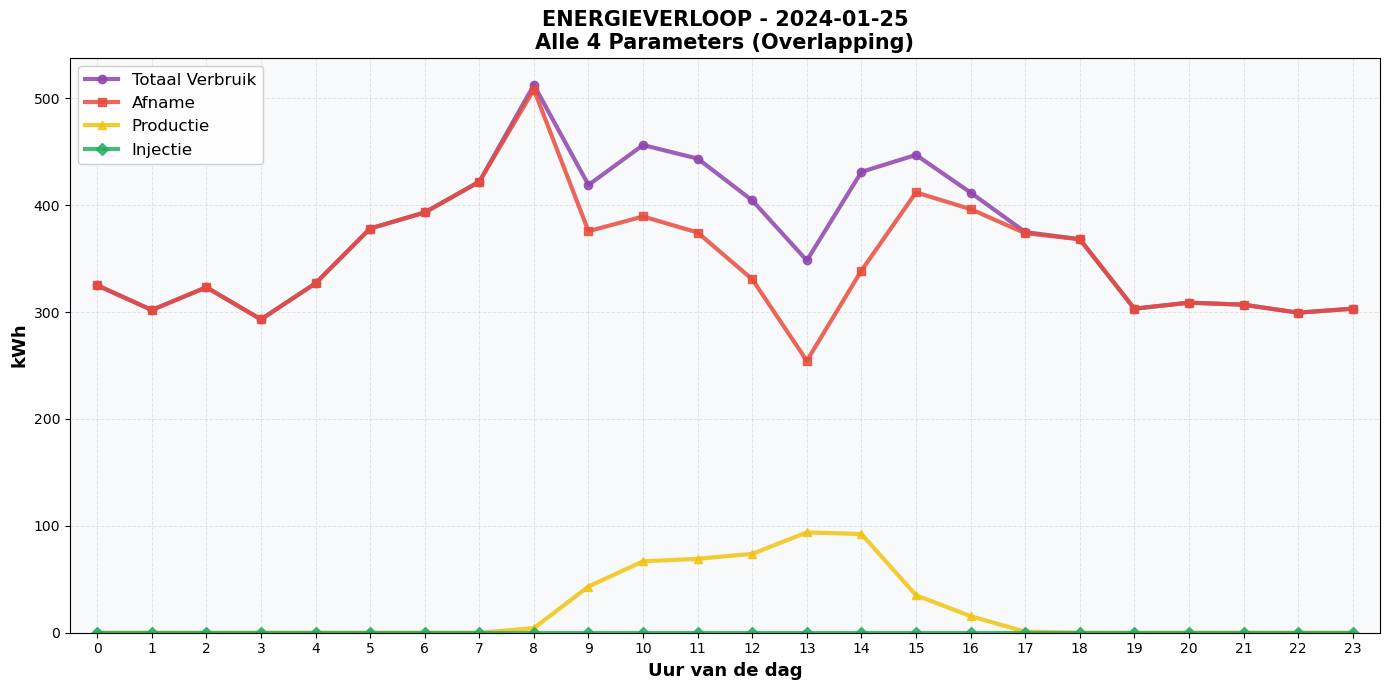


DETAIL PER UUR:
 uur  totaalverbruik  afname_kwh  productie_kwh  injectie_kwh
   0      325.000000     325.000       0.000000           0.0
   1      301.875000     301.875       0.000000           0.0
   2      323.125000     323.125       0.000000           0.0
   3      293.125000     293.125       0.000000           0.0
   4      326.875000     326.875       0.000000           0.0
   5      378.125000     378.125       0.000000           0.0
   6      393.125000     393.125       0.000000           0.0
   7      421.875000     421.875       0.000000           0.0
   8      512.443425     508.125       4.318425           0.0
   9      418.861080     375.625      43.236080           0.0
  10      456.187980     389.375      66.812980           0.0
  11      443.524423     374.375      69.149423           0.0
  12      404.391014     330.625      73.766014           0.0
  13      348.218133     254.375      93.843133           0.0
  14      431.088999     338.750      92.338999      

In [40]:
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====
selected_date = pd.Timestamp('2024-01-25').date()  # winterdag
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====

day_data = df_2024[df_2024['datetime'].dt.date == selected_date].copy()
day_data = day_data.sort_values('datetime')

if len(day_data) > 0:
    print(f"\nDag: {selected_date}")
    print(f"Totaal Verbruik: {day_data['totaalverbruik'].sum():.1f} kWh")
    print(f"Afname: {day_data['afname_kwh'].sum():.1f} kWh")
    print(f"Productie: {day_data['productie_kwh'].sum():.1f} kWh")
    print(f"Injectie: {day_data['injectie_kwh'].sum():.1f} kWh")
    
    # Aggregeer per uur
    hourly = day_data.groupby(day_data['datetime'].dt.hour).agg({
        'totaalverbruik': 'sum',
        'afname_kwh': 'sum',
        'productie_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    hourly.columns = ['uur', 'totaalverbruik', 'afname_kwh', 'productie_kwh', 'injectie_kwh']
    
    # OVERLAPPING LIJNEN - ALLE 4 PARAMETERS
    fig, ax = plt.subplots(figsize=(14, 7))
    
    hours = hourly['uur'].values
    
    # Zet negatieve waarden op 0
    verbruik = np.maximum(hourly['totaalverbruik'].values, 0)
    afname = np.maximum(hourly['afname_kwh'].values, 0)
    productie = np.maximum(hourly['productie_kwh'].values, 0)
    injectie = np.maximum(hourly['injectie_kwh'].values, 0)
    
    # OVERLAPPING LIJNEN met duidelijke kleuren
    ax.plot(hours, verbruik, 
            label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    
    ax.plot(hours, afname, 
            label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    
    ax.plot(hours, productie, 
            label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    
    ax.plot(hours, injectie, 
            label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    # Opmaak
    ax.set_xlabel('Uur van de dag', fontsize=13, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=13, fontweight='bold')
    ax.set_title(f'ENERGIEVERLOOP - {selected_date}\nAlle 4 Parameters (Overlapping)', 
                 fontsize=15, fontweight='bold')
    ax.set_xticks(range(0, 24, 1))
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(0, None)
    
    # Legend
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_facecolor('#F8F9FA')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("DETAIL PER UUR:")
    print("="*80)
    print(hourly.to_string(index=False))
else:
    print(f"Geen data voor {selected_date}")


Dag: 2025-06-05
Totaal Verbruik: 10730.3 kWh
Afname: 7461.2 kWh
Productie: 3643.4 kWh
Injectie: 374.4 kWh


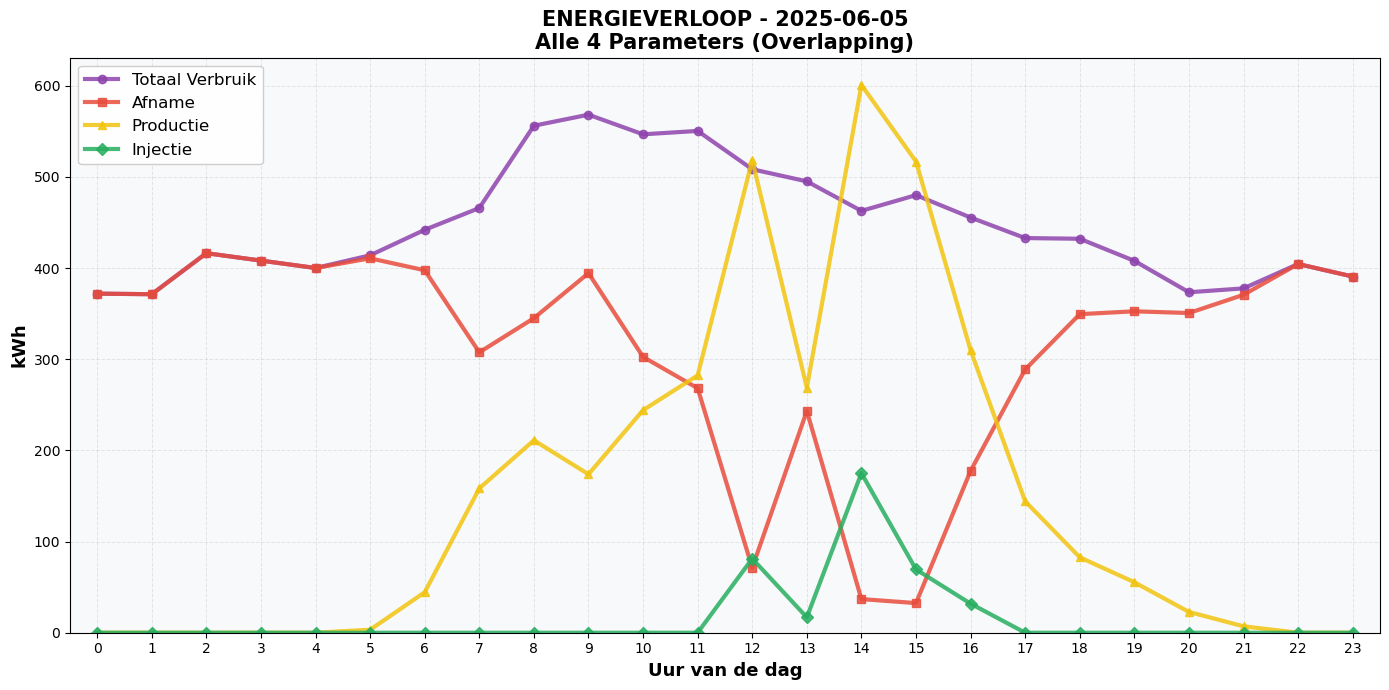


DETAIL PER UUR:
 uur  totaalverbruik  afname_kwh  productie_kwh  injectie_kwh
   0        371.8750     371.875         0.0000          0.00
   1        371.2500     371.250         0.0000          0.00
   2        416.2500     416.250         0.0000          0.00
   3        408.1250     408.125         0.0000          0.00
   4        400.0000     400.000         0.0000          0.00
   5        413.9020     410.625         3.2770          0.00
   6        441.8954     397.500        44.3954          0.00
   7        465.7895     307.500       158.2895          0.00
   8        556.0281     345.000       211.0281          0.00
   9        568.1550     394.375       173.7800          0.00
  10        546.6104     302.500       244.1104          0.00
  11        550.3301     268.125       282.2051          0.00
  12        508.3056      71.250       518.3156         81.26
  13        494.9993     243.125       268.7543         16.88
  14        462.6636      36.875       600.7886      

In [41]:
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====
selected_date = pd.Timestamp('2025-06-05').date()  # winterdag
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====

day_data = df_2025[df_2025['datetime'].dt.date == selected_date].copy()
day_data = day_data.sort_values('datetime')

if len(day_data) > 0:
    print(f"\nDag: {selected_date}")
    print(f"Totaal Verbruik: {day_data['totaalverbruik'].sum():.1f} kWh")
    print(f"Afname: {day_data['afname_kwh'].sum():.1f} kWh")
    print(f"Productie: {day_data['productie_kwh'].sum():.1f} kWh")
    print(f"Injectie: {day_data['injectie_kwh'].sum():.1f} kWh")
    
    # Aggregeer per uur
    hourly = day_data.groupby(day_data['datetime'].dt.hour).agg({
        'totaalverbruik': 'sum',
        'afname_kwh': 'sum',
        'productie_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    hourly.columns = ['uur', 'totaalverbruik', 'afname_kwh', 'productie_kwh', 'injectie_kwh']
    
    # OVERLAPPING LIJNEN - ALLE 4 PARAMETERS
    fig, ax = plt.subplots(figsize=(14, 7))
    
    hours = hourly['uur'].values
    
    # Zet negatieve waarden op 0
    verbruik = np.maximum(hourly['totaalverbruik'].values, 0)
    afname = np.maximum(hourly['afname_kwh'].values, 0)
    productie = np.maximum(hourly['productie_kwh'].values, 0)
    injectie = np.maximum(hourly['injectie_kwh'].values, 0)
    
    # OVERLAPPING LIJNEN met duidelijke kleuren
    ax.plot(hours, verbruik, 
            label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    
    ax.plot(hours, afname, 
            label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    
    ax.plot(hours, productie, 
            label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    
    ax.plot(hours, injectie, 
            label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    # Opmaak
    ax.set_xlabel('Uur van de dag', fontsize=13, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=13, fontweight='bold')
    ax.set_title(f'ENERGIEVERLOOP - {selected_date}\nAlle 4 Parameters (Overlapping)', 
                 fontsize=15, fontweight='bold')
    ax.set_xticks(range(0, 24, 1))
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(0, None)
    
    # Legend
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_facecolor('#F8F9FA')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("DETAIL PER UUR:")
    print("="*80)
    print(hourly.to_string(index=False))
else:
    print(f"Geen data voor {selected_date}")


Dag: 2025-01-27
Totaal Verbruik: 9822.5 kWh
Afname: 7830.0 kWh
Productie: 1992.5 kWh
Injectie: 0.0 kWh


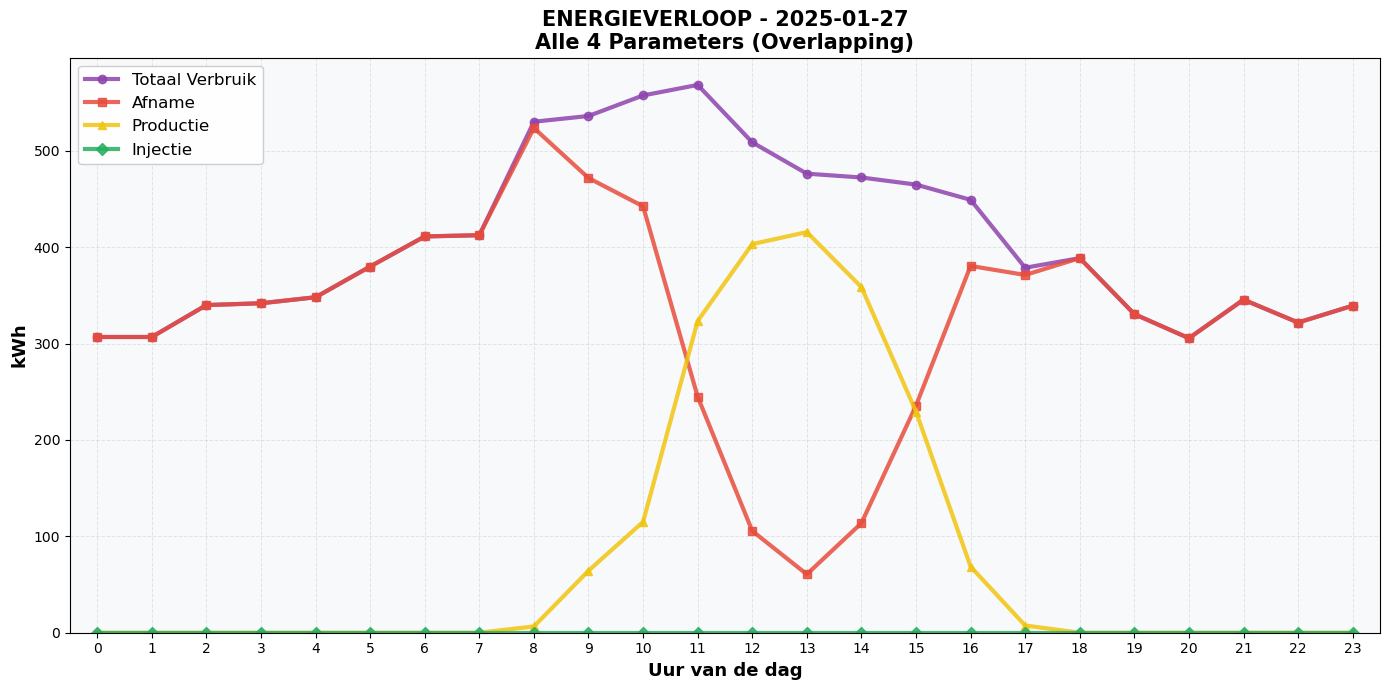


DETAIL PER UUR:
 uur  totaalverbruik  afname_kwh  productie_kwh  injectie_kwh
   0      306.875000     306.875       0.000000           0.0
   1      306.875000     306.875       0.000000           0.0
   2      340.000000     340.000       0.000000           0.0
   3      341.875000     341.875       0.000000           0.0
   4      348.125000     348.125       0.000000           0.0
   5      380.000000     380.000       0.000000           0.0
   6      411.250000     411.250       0.000000           0.0
   7      412.500000     412.500       0.000000           0.0
   8      530.274745     523.750       6.524745           0.0
   9      536.219974     471.875      64.344974           0.0
  10      557.536672     442.500     115.036672           0.0
  11      568.460761     245.000     323.460761           0.0
  12      508.891306     105.625     403.266306           0.0
  13      476.371189      60.625     415.746189           0.0
  14      472.395809     113.750     358.645809      

In [42]:
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====
selected_date = pd.Timestamp('2025-01-27').date()  # winterdag
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====

day_data = df_2025[df_2025['datetime'].dt.date == selected_date].copy()
day_data = day_data.sort_values('datetime')

if len(day_data) > 0:
    print(f"\nDag: {selected_date}")
    print(f"Totaal Verbruik: {day_data['totaalverbruik'].sum():.1f} kWh")
    print(f"Afname: {day_data['afname_kwh'].sum():.1f} kWh")
    print(f"Productie: {day_data['productie_kwh'].sum():.1f} kWh")
    print(f"Injectie: {day_data['injectie_kwh'].sum():.1f} kWh")
    
    # Aggregeer per uur
    hourly = day_data.groupby(day_data['datetime'].dt.hour).agg({
        'totaalverbruik': 'sum',
        'afname_kwh': 'sum',
        'productie_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    hourly.columns = ['uur', 'totaalverbruik', 'afname_kwh', 'productie_kwh', 'injectie_kwh']
    
    # OVERLAPPING LIJNEN - ALLE 4 PARAMETERS
    fig, ax = plt.subplots(figsize=(14, 7))
    
    hours = hourly['uur'].values
    
    # Zet negatieve waarden op 0
    verbruik = np.maximum(hourly['totaalverbruik'].values, 0)
    afname = np.maximum(hourly['afname_kwh'].values, 0)
    productie = np.maximum(hourly['productie_kwh'].values, 0)
    injectie = np.maximum(hourly['injectie_kwh'].values, 0)
    
    # OVERLAPPING LIJNEN met duidelijke kleuren
    ax.plot(hours, verbruik, 
            label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    
    ax.plot(hours, afname, 
            label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    
    ax.plot(hours, productie, 
            label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    
    ax.plot(hours, injectie, 
            label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    # Opmaak
    ax.set_xlabel('Uur van de dag', fontsize=13, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=13, fontweight='bold')
    ax.set_title(f'ENERGIEVERLOOP - {selected_date}\nAlle 4 Parameters (Overlapping)', 
                 fontsize=15, fontweight='bold')
    ax.set_xticks(range(0, 24, 1))
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(0, None)
    
    # Legend
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_facecolor('#F8F9FA')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("DETAIL PER UUR:")
    print("="*80)
    print(hourly.to_string(index=False))
else:
    print(f"Geen data voor {selected_date}")

## Grafiek 3: SPECIFIEKE WEEK - Alle 4 Parameters 
**Let op: Wijzig het weeknummer naar je keuze!**


Week: 26
Totaal verbruik: 48054.4 kWh
Afname: 21463.1 kWh
Productie: 52822.9 kWh
Injectie: 26231.6 kWh


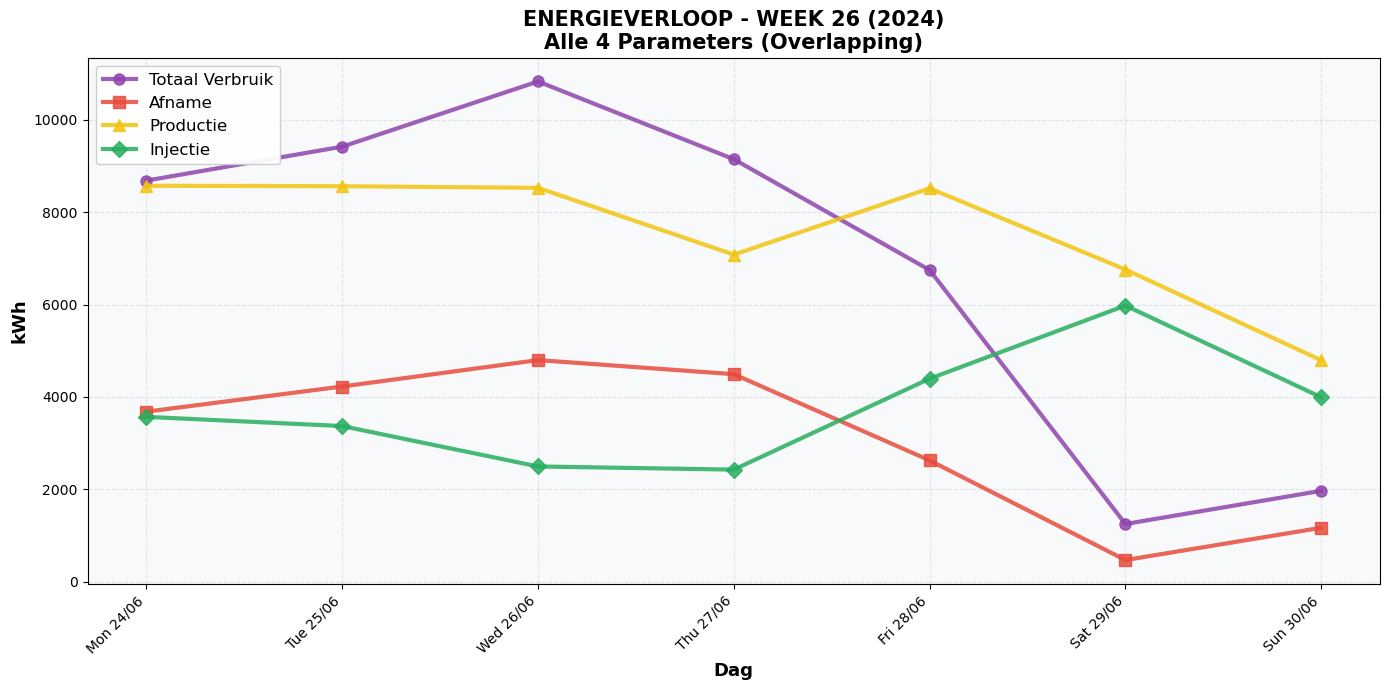

In [43]:
# ===== WIJZIG DEZE WEEK NAAR JE KEUZE =====
selected_week = 26  # Week 26 (juli)
# ===== WIJZIG DEZE WEEK NAAR JE KEUZE =====

week_data = df_2024[df_2024['datetime'].dt.isocalendar().week == selected_week].copy()
week_data = week_data.sort_values('datetime')

if len(week_data) > 0:
    print(f"\nWeek: {selected_week}")
    print(f"Totaal verbruik: {week_data['totaalverbruik'].sum():.1f} kWh")
    print(f"Afname: {week_data['afname_kwh'].sum():.1f} kWh")
    print(f"Productie: {week_data['productie_kwh'].sum():.1f} kWh")
    print(f"Injectie: {week_data['injectie_kwh'].sum():.1f} kWh")
    
    week_data['datum'] = week_data['datetime'].dt.date
    week_data['datum_label'] = week_data['datetime'].dt.strftime('%a %d/%m')
    
    # VOEG JAAR TOE
    year = week_data['datetime'].dt.year.iloc[0]
    
    daily_week = week_data.groupby(['datum', 'datum_label']).agg({
        'totaalverbruik': 'sum',
        'afname_kwh': 'sum',
        'productie_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    daily_week = daily_week.sort_values('datum')
    
    # OVERLAPPING LIJNEN
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x = np.arange(len(daily_week))
    verbruik = np.maximum(daily_week['totaalverbruik'].values, 0)
    afname = np.maximum(daily_week['afname_kwh'].values, 0)
    productie = np.maximum(daily_week['productie_kwh'].values, 0)
    injectie = np.maximum(daily_week['injectie_kwh'].values, 0)
    
    ax.plot(x, verbruik, label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=8, alpha=0.85)
    ax.plot(x, afname, label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=8, alpha=0.85)
    ax.plot(x, productie, label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=8, alpha=0.85)
    ax.plot(x, injectie, label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=8, alpha=0.85)
    
    ax.set_xlabel('Dag', fontsize=13, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=13, fontweight='bold')
    ax.set_title(f'ENERGIEVERLOOP - WEEK {selected_week} ({year})\nAlle 4 Parameters (Overlapping)', 
                 fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(daily_week['datum_label'].values, rotation=45, ha='right')
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#F8F9FA')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Geen data voor week {selected_week}")


Week: 26
Totaal verbruik: 57576.1 kWh
Afname: 32217.5 kWh
Productie: 30661.6 kWh
Injectie: 5302.4 kWh


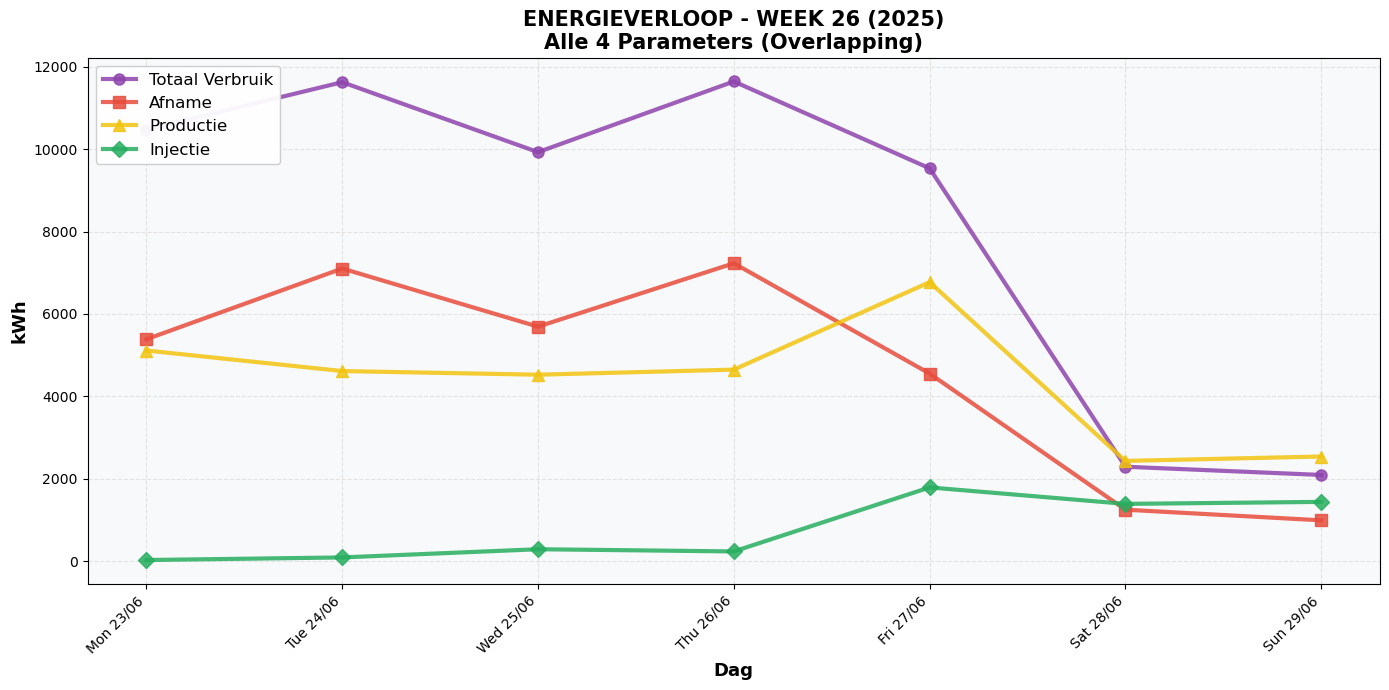

In [44]:
# ===== WIJZIG DEZE WEEK NAAR JE KEUZE =====
selected_week = 26  # Week 26 (september)
# ===== WIJZIG DEZE WEEK NAAR JE KEUZE =====

week_data = df_2025[df_2025['datetime'].dt.isocalendar().week == selected_week].copy()
week_data = week_data.sort_values('datetime')

if len(week_data) > 0:
    print(f"\nWeek: {selected_week}")
    print(f"Totaal verbruik: {week_data['totaalverbruik'].sum():.1f} kWh")
    print(f"Afname: {week_data['afname_kwh'].sum():.1f} kWh")
    print(f"Productie: {week_data['productie_kwh'].sum():.1f} kWh")
    print(f"Injectie: {week_data['injectie_kwh'].sum():.1f} kWh")
    
    week_data['datum'] = week_data['datetime'].dt.date
    week_data['datum_label'] = week_data['datetime'].dt.strftime('%a %d/%m')
    
    # VOEG JAAR TOE
    year = week_data['datetime'].dt.year.iloc[0]
    
    daily_week = week_data.groupby(['datum', 'datum_label']).agg({
        'totaalverbruik': 'sum',
        'afname_kwh': 'sum',
        'productie_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    daily_week = daily_week.sort_values('datum')
    
    # OVERLAPPING LIJNEN
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x = np.arange(len(daily_week))
    verbruik = np.maximum(daily_week['totaalverbruik'].values, 0)
    afname = np.maximum(daily_week['afname_kwh'].values, 0)
    productie = np.maximum(daily_week['productie_kwh'].values, 0)
    injectie = np.maximum(daily_week['injectie_kwh'].values, 0)
    
    ax.plot(x, verbruik, label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=8, alpha=0.85)
    ax.plot(x, afname, label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=8, alpha=0.85)
    ax.plot(x, productie, label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=8, alpha=0.85)
    ax.plot(x, injectie, label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=8, alpha=0.85)
    
    ax.set_xlabel('Dag', fontsize=13, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=13, fontweight='bold')
    ax.set_title(f'ENERGIEVERLOOP - WEEK {selected_week} ({year})\nAlle 4 Parameters (Overlapping)', 
                 fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(daily_week['datum_label'].values, rotation=45, ha='right')
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#F8F9FA')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Geen data voor week {selected_week}")

## Grafiek 4: SPECIFIEKE MAAND - Alle 4 Parameters


Maand: September 2024
Totale productie: 96806.5 kWh
Totaal verbruik: 207902.4 kWh
Totale injectie: 39847.2 kWh


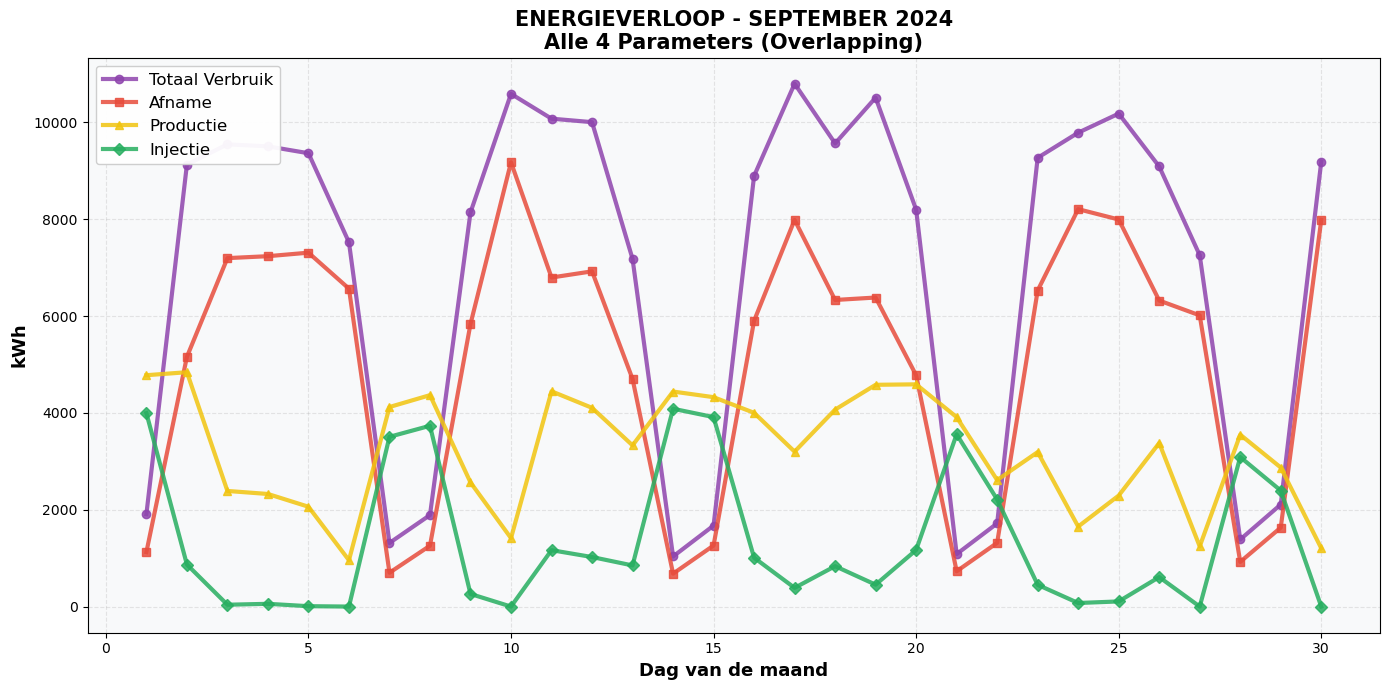

In [45]:
# ===== WIJZIG DEZE MAAND NAAR JE KEUZE =====
selected_month =  9 # 9 = september
# ===== WIJZIG DEZE MAAND NAAR JE KEUZE =====

month_data = df_2024[df_2024['datetime'].dt.month == selected_month].copy()
month_data = month_data.sort_values('datetime')

if len(month_data) > 0:
    maand_naam = month_data['datetime'].dt.strftime('%B').iloc[0]
    
    # VOEG JAAR TOE
    year = month_data['datetime'].dt.year.iloc[0]
    
    print(f"\nMaand: {maand_naam} {year}")
    print(f"Totale productie: {month_data['productie_kwh'].sum():.1f} kWh")
    print(f"Totaal verbruik: {month_data['totaalverbruik'].sum():.1f} kWh")
    print(f"Totale injectie: {month_data['injectie_kwh'].sum():.1f} kWh")
    
    month_data['dag'] = month_data['datetime'].dt.day
    
    daily_month = month_data.groupby('dag').agg({
        'totaalverbruik': 'sum',
        'afname_kwh': 'sum',
        'productie_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    dagen = daily_month['dag'].values
    verbruik = np.maximum(daily_month['totaalverbruik'].values, 0)
    afname = np.maximum(daily_month['afname_kwh'].values, 0)
    productie = np.maximum(daily_month['productie_kwh'].values, 0)
    injectie = np.maximum(daily_month['injectie_kwh'].values, 0)
    
    ax.plot(dagen, verbruik, label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    ax.plot(dagen, afname, label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    ax.plot(dagen, productie, label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    ax.plot(dagen, injectie, label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    ax.set_xlabel('Dag van de maand', fontsize=13, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=13, fontweight='bold')
    ax.set_title(f'ENERGIEVERLOOP - {maand_naam.upper()} {year}\nAlle 4 Parameters (Overlapping)', 
                 fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#F8F9FA')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Geen data voor maand {selected_month}")


Maand: September 2025
Totale productie: 99196.5 kWh
Totaal verbruik: 234122.1 kWh
Totale injectie: 21285.1 kWh


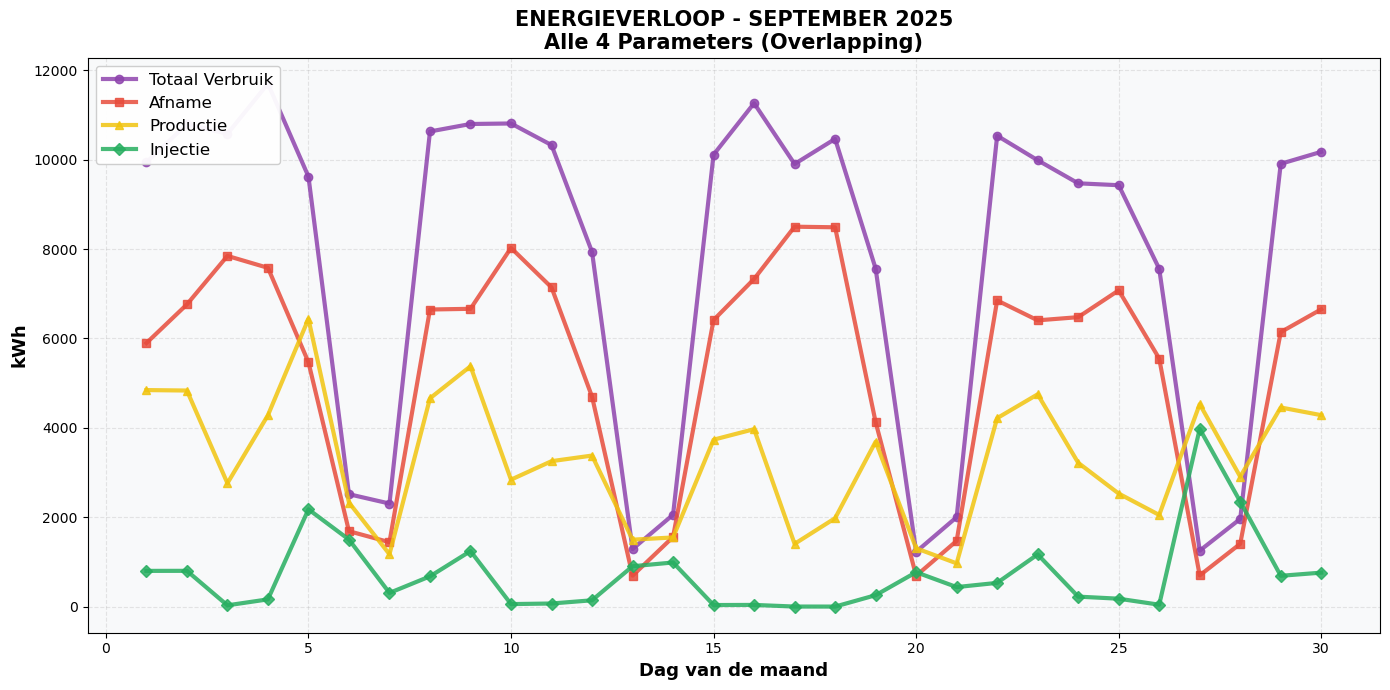

In [46]:
# ===== WIJZIG DEZE MAAND NAAR JE KEUZE =====
selected_month = 9  # 9 = september
# ===== WIJZIG DEZE MAAND NAAR JE KEUZE =====

month_data = df_2025[df_2025['datetime'].dt.month == selected_month].copy()
month_data = month_data.sort_values('datetime')

if len(month_data) > 0:
    maand_naam = month_data['datetime'].dt.strftime('%B').iloc[0]
    
    # VOEG JAAR TOE
    year = month_data['datetime'].dt.year.iloc[0]
    
    print(f"\nMaand: {maand_naam} {year}")
    print(f"Totale productie: {month_data['productie_kwh'].sum():.1f} kWh")
    print(f"Totaal verbruik: {month_data['totaalverbruik'].sum():.1f} kWh")
    print(f"Totale injectie: {month_data['injectie_kwh'].sum():.1f} kWh")
    
    month_data['dag'] = month_data['datetime'].dt.day
    
    daily_month = month_data.groupby('dag').agg({
        'totaalverbruik': 'sum',
        'afname_kwh': 'sum',
        'productie_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    dagen = daily_month['dag'].values
    verbruik = np.maximum(daily_month['totaalverbruik'].values, 0)
    afname = np.maximum(daily_month['afname_kwh'].values, 0)
    productie = np.maximum(daily_month['productie_kwh'].values, 0)
    injectie = np.maximum(daily_month['injectie_kwh'].values, 0)
    
    ax.plot(dagen, verbruik, label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    ax.plot(dagen, afname, label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    ax.plot(dagen, productie, label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    ax.plot(dagen, injectie, label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    ax.set_xlabel('Dag van de maand', fontsize=13, fontweight='bold')
    ax.set_ylabel('kWh', fontsize=13, fontweight='bold')
    ax.set_title(f'ENERGIEVERLOOP - {maand_naam.upper()} {year}\nAlle 4 Parameters (Overlapping)', 
                 fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#F8F9FA')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Geen data voor maand {selected_month}")

## Grafiek 5: VERGELIJKING - Dezelfde Dag 2024 vs 2025

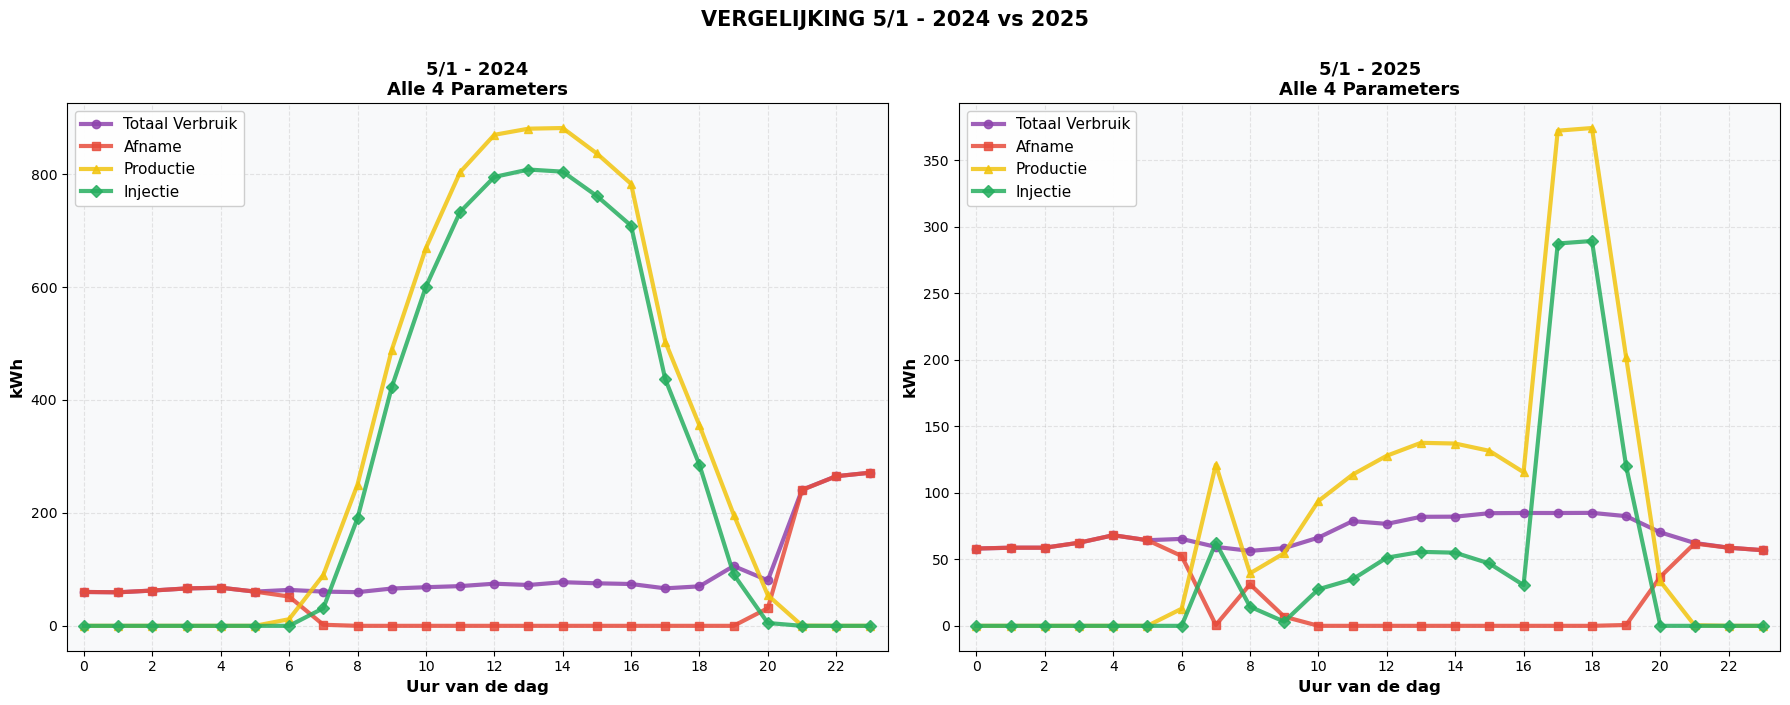


DETAIL 5/1 - 2024
 uur  totaalverbruik  productie_kwh  afname_kwh  injectie_kwh
   0       60.000000       0.000000      60.000          0.00
   1       59.375000       0.000000      59.375          0.00
   2       62.500000       0.000000      62.500          0.00
   3       66.250000       0.000000      66.250          0.00
   4       67.500000       0.000000      67.500          0.00
   5       60.625000       0.000000      60.625          0.00
   6       63.622979      11.747979      51.875          0.00
   7       60.609049      90.004049       1.875         31.27
   8       59.627051     250.257051       0.000        190.63
   9       66.052031     488.552031       0.000        422.50
  10       68.395321     669.035321       0.000        600.64
  11       70.331312     803.461312       0.000        733.13
  12       74.627959     869.637959       0.000        795.01
  13       72.352836     880.492836       0.000        808.14
  14       77.282750     881.672750       0.000    

In [47]:
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====
comp_month = 5  # 5 = mei
comp_day = 1   # 1de
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====

comp_2024 = df_2024[(df_2024['datetime'].dt.month == comp_month) & 
                    (df_2024['datetime'].dt.day == comp_day)].copy()
comp_2025 = df_2025[(df_2025['datetime'].dt.month == comp_month) & 
                    (df_2025['datetime'].dt.day == comp_day)].copy()

if len(comp_2024) > 0 and len(comp_2025) > 0:
    # Aggregeer alle 4 parameters per uur
    hourly_2024 = comp_2024.groupby(comp_2024['datetime'].dt.hour).agg({
        'totaalverbruik': 'sum',
        'productie_kwh': 'sum',
        'afname_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    hourly_2024.columns = ['uur', 'totaalverbruik', 'productie_kwh', 'afname_kwh', 'injectie_kwh']
    
    hourly_2025 = comp_2025.groupby(comp_2025['datetime'].dt.hour).agg({
        'totaalverbruik': 'sum',
        'productie_kwh': 'sum',
        'afname_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    hourly_2025.columns = ['uur', 'totaalverbruik', 'productie_kwh', 'afname_kwh', 'injectie_kwh']
    
    # ============================================================
    # TWEE GRAFIEKEN - 2024 EN 2025 NAAST ELKAAR
    # ============================================================
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # -------- GRAFIEK 1: 2024 --------
    hours_24 = hourly_2024['uur'].values
    verbruik_24 = np.maximum(hourly_2024['totaalverbruik'].values, 0)
    afname_24 = np.maximum(hourly_2024['afname_kwh'].values, 0)
    productie_24 = np.maximum(hourly_2024['productie_kwh'].values, 0)
    injectie_24 = np.maximum(hourly_2024['injectie_kwh'].values, 0)
    
    ax1.plot(hours_24, verbruik_24, label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    ax1.plot(hours_24, afname_24, label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    ax1.plot(hours_24, productie_24, label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    ax1.plot(hours_24, injectie_24, label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    ax1.set_xlabel('Uur van de dag', fontsize=12, fontweight='bold')
    ax1.set_ylabel('kWh', fontsize=12, fontweight='bold')
    ax1.set_title(f'{comp_month}/{comp_day} - 2024\nAlle 4 Parameters', fontsize=13, fontweight='bold')
    ax1.set_xticks(range(0, 24, 2))
    ax1.set_xlim(-0.5, 23.5)
    ax1.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_facecolor('#F8F9FA')
    
    # -------- GRAFIEK 2: 2025 --------
    hours_25 = hourly_2025['uur'].values
    verbruik_25 = np.maximum(hourly_2025['totaalverbruik'].values, 0)
    afname_25 = np.maximum(hourly_2025['afname_kwh'].values, 0)
    productie_25 = np.maximum(hourly_2025['productie_kwh'].values, 0)
    injectie_25 = np.maximum(hourly_2025['injectie_kwh'].values, 0)
    
    ax2.plot(hours_25, verbruik_25, label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    ax2.plot(hours_25, afname_25, label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    ax2.plot(hours_25, productie_25, label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    ax2.plot(hours_25, injectie_25, label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    ax2.set_xlabel('Uur van de dag', fontsize=12, fontweight='bold')
    ax2.set_ylabel('kWh', fontsize=12, fontweight='bold')
    ax2.set_title(f'{comp_month}/{comp_day} - 2025\nAlle 4 Parameters', fontsize=13, fontweight='bold')
    ax2.set_xticks(range(0, 24, 2))
    ax2.set_xlim(-0.5, 23.5)
    ax2.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_facecolor('#F8F9FA')
    
    fig.suptitle(f'VERGELIJKING {comp_month}/{comp_day} - 2024 vs 2025', fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # ============================================================
    # TABELLEN
    # ============================================================
    
    print(f"\n{'='*110}")
    print(f"DETAIL {comp_month}/{comp_day} - 2024")
    print(f"{'='*110}")
    print(hourly_2024.to_string(index=False))
    
    print(f"\n{'='*110}")
    print(f"DETAIL {comp_month}/{comp_day} - 2025")
    print(f"{'='*110}")
    print(hourly_2025.to_string(index=False))
    
    # ============================================================
    # VERSCHIL TABEL
    # ============================================================
    
    print(f"\n{'='*110}")
    print(f"VERSCHIL (2025 - 2024) - Positief = meer in 2025")
    print(f"{'='*110}")
    
    verschil = pd.DataFrame({
        'uur': hourly_2024['uur'],
        'verbruik_diff': (hourly_2025['totaalverbruik'].values - hourly_2024['totaalverbruik'].values).round(1),
        'afname_diff': (hourly_2025['afname_kwh'].values - hourly_2024['afname_kwh'].values).round(1),
        'productie_diff': (hourly_2025['productie_kwh'].values - hourly_2024['productie_kwh'].values).round(1),
        'injectie_diff': (hourly_2025['injectie_kwh'].values - hourly_2024['injectie_kwh'].values).round(1)
    })
    
    print(verschil.to_string(index=False))
    
    # ============================================================
    # SAMENVATTING
    # ============================================================
    
    print(f"\n{'='*110}")
    print(f"SAMENVATTING")
    print(f"{'='*110}")
    
    print(f"\n2024 TOTALEN:")
    print(f"  Totaal Verbruik: {hourly_2024['totaalverbruik'].sum():.1f} kWh")
    print(f"  Afname:          {hourly_2024['afname_kwh'].sum():.1f} kWh")
    print(f"  Productie:       {hourly_2024['productie_kwh'].sum():.1f} kWh")
    print(f"  Injectie:        {hourly_2024['injectie_kwh'].sum():.1f} kWh")
    
    print(f"\n2025 TOTALEN:")
    print(f"  Totaal Verbruik: {hourly_2025['totaalverbruik'].sum():.1f} kWh")
    print(f"  Afname:          {hourly_2025['afname_kwh'].sum():.1f} kWh")
    print(f"  Productie:       {hourly_2025['productie_kwh'].sum():.1f} kWh")
    print(f"  Injectie:        {hourly_2025['injectie_kwh'].sum():.1f} kWh")
    
    print(f"\nVERSCHIL (2025 - 2024):")
    print(f"  Totaal Verbruik: {(hourly_2025['totaalverbruik'].sum() - hourly_2024['totaalverbruik'].sum()):+.1f} kWh")
    print(f"  Afname:          {(hourly_2025['afname_kwh'].sum() - hourly_2024['afname_kwh'].sum()):+.1f} kWh")
    print(f"  Productie:       {(hourly_2025['productie_kwh'].sum() - hourly_2024['productie_kwh'].sum()):+.1f} kWh")
    print(f"  Injectie:        {(hourly_2025['injectie_kwh'].sum() - hourly_2024['injectie_kwh'].sum()):+.1f} kWh")
    
else:
    print(f"Geen data voor {comp_month}/{comp_day}")


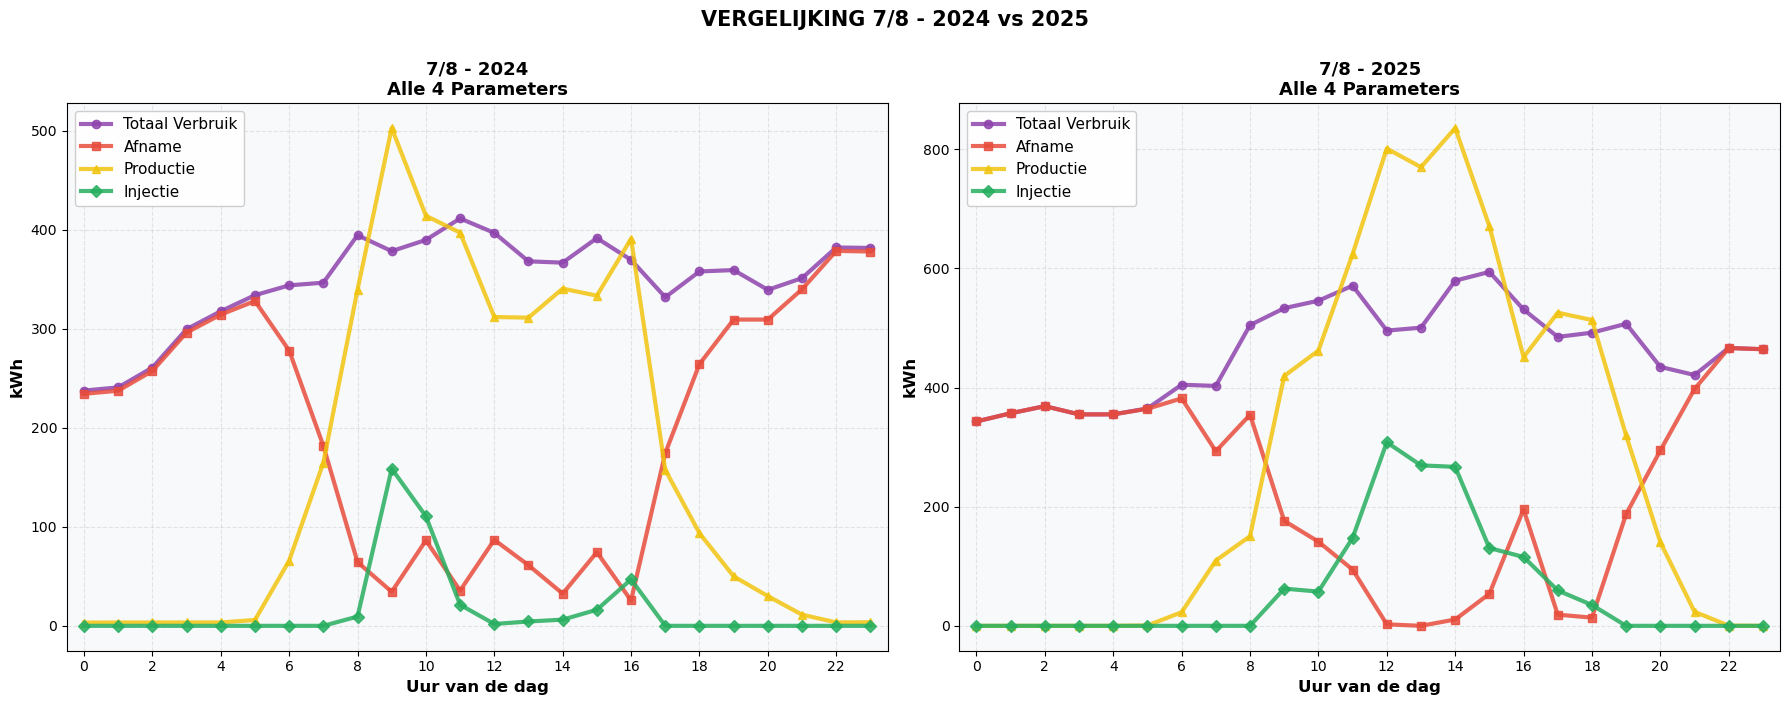


DETAIL 7/8 - 2024
 uur  totaalverbruik  productie_kwh  afname_kwh  injectie_kwh
   0      237.653826       3.278826     234.375          0.00
   1      240.853712       3.353712     237.500          0.00
   2      260.881144       3.381144     257.500          0.00
   3      299.649210       3.399210     296.250          0.00
   4      317.787791       3.412791     314.375          0.00
   5      334.012741       5.887741     328.125          0.00
   6      343.938903      65.813903     278.125          0.00
   7      346.634612     164.759612     181.875          0.00
   8      394.617996     339.612996      64.375          9.37
   9      378.483450     502.868450      34.375        158.76
  10      389.837650     414.227650      86.250        110.64
  11      411.545112     397.180112      35.625         21.26
  12      396.947700     311.952700      86.875          1.88
  13      368.197260     311.327260      61.250          4.38
  14      366.879791     340.629791      32.500    

In [59]:
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====
comp_month = 7  # 7 = juli
comp_day = 8   # 8de
# ===== WIJZIG DEZE DATUM NAAR JE KEUZE =====

comp_2024 = df_2024[(df_2024['datetime'].dt.month == comp_month) & 
                    (df_2024['datetime'].dt.day == comp_day)].copy()
comp_2025 = df_2025[(df_2025['datetime'].dt.month == comp_month) & 
                    (df_2025['datetime'].dt.day == comp_day)].copy()

if len(comp_2024) > 0 and len(comp_2025) > 0:
    # Aggregeer alle 4 parameters per uur
    hourly_2024 = comp_2024.groupby(comp_2024['datetime'].dt.hour).agg({
        'totaalverbruik': 'sum',
        'productie_kwh': 'sum',
        'afname_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    hourly_2024.columns = ['uur', 'totaalverbruik', 'productie_kwh', 'afname_kwh', 'injectie_kwh']
    
    hourly_2025 = comp_2025.groupby(comp_2025['datetime'].dt.hour).agg({
        'totaalverbruik': 'sum',
        'productie_kwh': 'sum',
        'afname_kwh': 'sum',
        'injectie_kwh': 'sum'
    }).reset_index()
    hourly_2025.columns = ['uur', 'totaalverbruik', 'productie_kwh', 'afname_kwh', 'injectie_kwh']
    
    # ============================================================
    # TWEE GRAFIEKEN - 2024 EN 2025 NAAST ELKAAR
    # ============================================================
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # -------- GRAFIEK 1: 2024 --------
    hours_24 = hourly_2024['uur'].values
    verbruik_24 = np.maximum(hourly_2024['totaalverbruik'].values, 0)
    afname_24 = np.maximum(hourly_2024['afname_kwh'].values, 0)
    productie_24 = np.maximum(hourly_2024['productie_kwh'].values, 0)
    injectie_24 = np.maximum(hourly_2024['injectie_kwh'].values, 0)
    
    ax1.plot(hours_24, verbruik_24, label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    ax1.plot(hours_24, afname_24, label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    ax1.plot(hours_24, productie_24, label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    ax1.plot(hours_24, injectie_24, label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    ax1.set_xlabel('Uur van de dag', fontsize=12, fontweight='bold')
    ax1.set_ylabel('kWh', fontsize=12, fontweight='bold')
    ax1.set_title(f'{comp_month}/{comp_day} - 2024\nAlle 4 Parameters', fontsize=13, fontweight='bold')
    ax1.set_xticks(range(0, 24, 2))
    ax1.set_xlim(-0.5, 23.5)
    ax1.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_facecolor('#F8F9FA')
    
    # -------- GRAFIEK 2: 2025 --------
    hours_25 = hourly_2025['uur'].values
    verbruik_25 = np.maximum(hourly_2025['totaalverbruik'].values, 0)
    afname_25 = np.maximum(hourly_2025['afname_kwh'].values, 0)
    productie_25 = np.maximum(hourly_2025['productie_kwh'].values, 0)
    injectie_25 = np.maximum(hourly_2025['injectie_kwh'].values, 0)
    
    ax2.plot(hours_25, verbruik_25, label='Totaal Verbruik', color='#8E44AD', linewidth=3, marker='o', markersize=6, alpha=0.85)
    ax2.plot(hours_25, afname_25, label='Afname', color='#E74C3C', linewidth=3, marker='s', markersize=6, alpha=0.85)
    ax2.plot(hours_25, productie_25, label='Productie', color='#F1C40F', linewidth=3, marker='^', markersize=6, alpha=0.85)
    ax2.plot(hours_25, injectie_25, label='Injectie', color='#27AE60', linewidth=3, marker='D', markersize=6, alpha=0.85)
    
    ax2.set_xlabel('Uur van de dag', fontsize=12, fontweight='bold')
    ax2.set_ylabel('kWh', fontsize=12, fontweight='bold')
    ax2.set_title(f'{comp_month}/{comp_day} - 2025\nAlle 4 Parameters', fontsize=13, fontweight='bold')
    ax2.set_xticks(range(0, 24, 2))
    ax2.set_xlim(-0.5, 23.5)
    ax2.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_facecolor('#F8F9FA')
    
    fig.suptitle(f'VERGELIJKING {comp_month}/{comp_day} - 2024 vs 2025', fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # ============================================================
    # TABELLEN
    # ============================================================
    
    print(f"\n{'='*110}")
    print(f"DETAIL {comp_month}/{comp_day} - 2024")
    print(f"{'='*110}")
    print(hourly_2024.to_string(index=False))
    
    print(f"\n{'='*110}")
    print(f"DETAIL {comp_month}/{comp_day} - 2025")
    print(f"{'='*110}")
    print(hourly_2025.to_string(index=False))
    
    # ============================================================
    # VERSCHIL TABEL
    # ============================================================
    
    print(f"\n{'='*110}")
    print(f"VERSCHIL (2025 - 2024) - Positief = meer in 2025")
    print(f"{'='*110}")
    
    verschil = pd.DataFrame({
        'uur': hourly_2024['uur'],
        'verbruik_diff': (hourly_2025['totaalverbruik'].values - hourly_2024['totaalverbruik'].values).round(1),
        'afname_diff': (hourly_2025['afname_kwh'].values - hourly_2024['afname_kwh'].values).round(1),
        'productie_diff': (hourly_2025['productie_kwh'].values - hourly_2024['productie_kwh'].values).round(1),
        'injectie_diff': (hourly_2025['injectie_kwh'].values - hourly_2024['injectie_kwh'].values).round(1)
    })
    
    print(verschil.to_string(index=False))
    
    # ============================================================
    # SAMENVATTING
    # ============================================================
    
    print(f"\n{'='*110}")
    print(f"SAMENVATTING")
    print(f"{'='*110}")
    
    print(f"\n2024 TOTALEN:")
    print(f"  Totaal Verbruik: {hourly_2024['totaalverbruik'].sum():.1f} kWh")
    print(f"  Afname:          {hourly_2024['afname_kwh'].sum():.1f} kWh")
    print(f"  Productie:       {hourly_2024['productie_kwh'].sum():.1f} kWh")
    print(f"  Injectie:        {hourly_2024['injectie_kwh'].sum():.1f} kWh")
    
    print(f"\n2025 TOTALEN:")
    print(f"  Totaal Verbruik: {hourly_2025['totaalverbruik'].sum():.1f} kWh")
    print(f"  Afname:          {hourly_2025['afname_kwh'].sum():.1f} kWh")
    print(f"  Productie:       {hourly_2025['productie_kwh'].sum():.1f} kWh")
    print(f"  Injectie:        {hourly_2025['injectie_kwh'].sum():.1f} kWh")
    
    print(f"\nVERSCHIL (2025 - 2024):")
    print(f"  Totaal Verbruik: {(hourly_2025['totaalverbruik'].sum() - hourly_2024['totaalverbruik'].sum()):+.1f} kWh")
    print(f"  Afname:          {(hourly_2025['afname_kwh'].sum() - hourly_2024['afname_kwh'].sum()):+.1f} kWh")
    print(f"  Productie:       {(hourly_2025['productie_kwh'].sum() - hourly_2024['productie_kwh'].sum()):+.1f} kWh")
    print(f"  Injectie:        {(hourly_2025['injectie_kwh'].sum() - hourly_2024['injectie_kwh'].sum()):+.1f} kWh")
    
else:
    print(f"Geen data voor {comp_month}/{comp_day}")
